In [1]:
# ─── CELL 1 — Lightning AI Studio Environment ────────────────────────────────
import os

BASE_DATASET = "/teamspace/studios/this_studio/Dataset"
OUT = "/teamspace/studios/this_studio/outputs"
os.makedirs(OUT, exist_ok=True)

print("📂 Dataset files found:")
for f in sorted(os.listdir(BASE_DATASET)):
    fpath = os.path.join(BASE_DATASET, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"   {f:<40} {size_kb:>8.1f} KB")

print(f"\n✅ Output dir ready: {OUT}")


📂 Dataset files found:
   class_weights.npy                             0.1 KB
   feature_cols.pkl                              0.3 KB
   fold_indices.pkl                            169.1 KB
   label_encoder.pkl                             0.3 KB
   scaler.pkl                                    1.2 KB
   test.csv                                    725.6 KB
   train_raw.csv                              3384.5 KB
   train_smote.csv                            8706.5 KB
   val.csv                                     725.2 KB

✅ Output dir ready: /teamspace/studios/this_studio/outputs


In [2]:
# ─── CELL 2 — H200 Environment Check ─────────────────────────────────────────
import sys, importlib

packages = {
    'numpy': 'numpy', 'pandas': 'pandas',
    'sklearn': 'scikit-learn', 'torch': 'torch',
    'xgboost': 'xgboost', 'lightgbm': 'lightgbm',
    'shap': 'shap', 'imblearn': 'imbalanced-learn',
    'matplotlib': 'matplotlib', 'seaborn': 'seaborn',
}

print("Package versions on Lightning AI Studio:")
for imp_name, pkg_name in packages.items():
    try:
        mod = importlib.import_module(imp_name)
        ver = getattr(mod, '__version__', '?')
        print(f"  ✅ {pkg_name:<22} {ver}")
    except ImportError:
        print(f"  ❌ {pkg_name} NOT FOUND — run: !pip install {pkg_name} -q")

import torch

print(f"\n{'='*50}")
print(f"  GPU available     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU name          : {gpu_name}")
    print(f"  Total VRAM        : {total_mem:.1f} GB")
    print(f"  CUDA version      : {torch.version.cuda}")
    print(f"  BF16 supported    : {torch.cuda.is_bf16_supported()}")
    cc = torch.cuda.get_device_capability(0)
    print(f"  Compute Capability: {cc[0]}.{cc[1]}")
    if "H200" in gpu_name or cc[0] >= 9:
        print(f"\n  🚀 H200 DETECTED — HBM3e, FlashAttn-3, BF16/FP8 ready!")
    else:
        print(f"\n  ⚠️  GPU: {gpu_name} — H200 optimisations still safe to use")
print(f"{'='*50}")


Package versions on Lightning AI Studio:
  ✅ numpy                  1.26.4


  ✅ pandas                 3.0.1
  ✅ scikit-learn           1.5.2
  ✅ torch                  2.8.0+cu128
  ✅ xgboost                3.2.0
  ✅ lightgbm               4.6.0
  ✅ shap                   0.51.0
  ✅ imbalanced-learn       0.14.1
  ✅ matplotlib             3.8.2
  ✅ seaborn                0.13.2

  GPU available     : True
  GPU name          : NVIDIA H200
  Total VRAM        : 150.1 GB
  CUDA version      : 12.8
  BF16 supported    : True
  Compute Capability: 9.0

  🚀 H200 DETECTED — HBM3e, FlashAttn-3, BF16/FP8 ready!


In [3]:
# ─── FIX — Upgrade scikit-learn to resolve _isin ImportError ─────────────────
import subprocess, sys

print("🔧 Upgrading scikit-learn and scipy for compatibility...")

upgrades = [
    ("scikit-learn", "1.5.2"),   # stable, has _isin, works with Python 3.12
    ("scipy",        "1.13.1"),  # needed by sklearn 1.5.x + imbalanced-learn
    ("threadpoolctl","3.5.0"),   # sklearn runtime dep
]

for pkg, ver in upgrades:
    print(f"   📦 Installing {pkg}=={ver} ...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", f"{pkg}=={ver}", "-q"],
        stdout=subprocess.DEVNULL
    )
    print(f"   ✅ {pkg}=={ver} done")

# Verify
import importlib
import sklearn, scipy
print(f"\n✅ sklearn  : {sklearn.__version__}  (need ≥1.4)")
print(f"✅ scipy    : {scipy.__version__}  (need ≥1.11)")
print("\n⚠️  IMPORTANT: Go to Kernel → Restart Kernel, then re-run from Cell 3")


🔧 Upgrading scikit-learn and scipy for compatibility...
   📦 Installing scikit-learn==1.5.2 ...


   ✅ scikit-learn==1.5.2 done
   📦 Installing scipy==1.13.1 ...
   ✅ scipy==1.13.1 done
   📦 Installing threadpoolctl==3.5.0 ...
   ✅ threadpoolctl==3.5.0 done

✅ sklearn  : 1.5.2  (need ≥1.4)
✅ scipy    : 1.13.1  (need ≥1.11)

⚠️  IMPORTANT: Go to Kernel → Restart Kernel, then re-run from Cell 3


In [4]:
# ─── CELL 3 — Imports + H200 Backend Optimisations ───────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle, os, time, json
from pathlib import Path

# Sklearn
from sklearn.preprocessing import QuantileTransformer, label_binarize
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight

# Tree models
import xgboost as xgb
import lightgbm as lgb

# SHAP
import shap

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

# ─── H200 Backend Flags ───────────────────────────────────────────────────────
# TF32 gives ~3x speedup on matrix ops with negligible accuracy loss on H200
torch.backends.cuda.matmul.allow_tf32  = True
torch.backends.cudnn.allow_tf32        = True
torch.backends.cudnn.benchmark         = True   # auto-tune kernels for fixed input sizes

# BF16 is the preferred dtype on H200 (more stable than FP16, faster than FP32)
COMPUTE_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

# ─── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# NOTE: deterministic=True disabled intentionally — FlashAttn-3 non-deterministic
# but gives massive speedup. Re-enable only if exact reproducibility required.
torch.backends.cudnn.deterministic = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ All imports successful")
print(f"✅ Device        : {device}")
print(f"✅ Compute dtype : {COMPUTE_DTYPE}")
print(f"✅ TF32 enabled  : {torch.backends.cuda.matmul.allow_tf32}")


✅ All imports successful
✅ Device        : cuda
✅ Compute dtype : torch.bfloat16
✅ TF32 enabled  : True


In [5]:
# ─── CELL 4 — H200 Configuration ─────────────────────────────────────────────

# ── Paths (Lightning AI Studio) ───────────────────────────────────────────────
BASE = "/teamspace/studios/this_studio/Dataset"
OUT  = "/teamspace/studios/this_studio/outputs"
os.makedirs(OUT, exist_ok=True)

TRAIN_RAW_PATH   = f"{BASE}/train_raw.csv"
TRAIN_SMOTE_PATH = f"{BASE}/train_smote.csv"
VAL_PATH         = f"{BASE}/val.csv"
TEST_PATH        = f"{BASE}/test.csv"
LE_PATH          = f"{BASE}/label_encoder.pkl"
CW_PATH          = f"{BASE}/class_weights.npy"
FEAT_PATH        = f"{BASE}/feature_cols.pkl"
SCALER_PATH      = f"{BASE}/scaler.pkl"
FOLD_PATH        = f"{BASE}/fold_indices.pkl"

TARGET_COL = "Disease_Label"

# ── Stratified K-Fold ─────────────────────────────────────────────────────────
N_FOLDS = 5

# ── FT-Transformer (H200 Scaled) ──────────────────────────────────────────────
# H200 HBM3e (141 GB) allows much larger token dim and deeper network
D_TOKEN      = 256      # ⬆ was 192 — richer per-feature embedding
N_LAYERS     = 6        # ⬆ was 4  — deeper attention stack
N_HEADS      = 8        # same    — keeps d_head=32 clean
FFN_FACTOR   = 4 / 3
ATTN_DROPOUT = 0.10
FFN_DROPOUT  = 0.15

# ── Training (H200 can push far larger batches) ───────────────────────────────
BATCH_SIZE  = 1024      # ⬆ was 256 — fills HBM3e, better gradient estimates
MAX_EPOCHS  = 500       # ⬆ was 400 — H200 trains ~5× faster than T4
PATIENCE    = 60        # ⬆ was 50
LR          = 2e-3
WEIGHT_DECAY= 1e-4

# ── Advanced Augmentations ────────────────────────────────────────────────────
LABEL_SMOOTHING = 0.05
FOCAL_GAMMA     = 2.0
MIXUP_ALPHA     = 0.40

FT_SEEDS = [42, 123, 456]

# ── DNN ───────────────────────────────────────────────────────────────────────
DNN_EPOCHS  = 150       # ⬆ was 100
DNN_PATIENCE= 20        # ⬆ was 15
DNN_LR      = 1e-3
DNN_WD      = 1e-4
DNN_BATCH   = 1024      # ⬆ was 256

# ── XGBoost / LightGBM ────────────────────────────────────────────────────────
N_EST  = 800            # ⬆ was 600 — more trees, H200 GPU hist is fast
DEPTH  = 6
GB_LR  = 0.03

# ── DataLoader Workers (Lightning AI has many CPU cores) ─────────────────────
NUM_WORKERS  = 4
PIN_MEMORY   = True     # speeds up CPU→GPU transfer on H200 NVLink

# ── AMP Scaler (BF16 doesn't need GradScaler but keep for safety) ─────────────
USE_AMP = True

print(f"✅ H200 Config ready")
print(f"   FT  : D={D_TOKEN} | L={N_LAYERS} | H={N_HEADS} | Batch={BATCH_SIZE}")
print(f"   DNN : Batch={DNN_BATCH} | Epochs={DNN_EPOCHS}")
print(f"   XGB : N_est={N_EST} | Depth={DEPTH}")
print(f"   AMP : {USE_AMP} (dtype={COMPUTE_DTYPE})")
print(f"   {N_FOLDS}-Fold CV | Output → {OUT}")


✅ H200 Config ready
   FT  : D=256 | L=6 | H=8 | Batch=1024
   DNN : Batch=1024 | Epochs=150
   XGB : N_est=800 | Depth=6
   AMP : True (dtype=torch.bfloat16)
   5-Fold CV | Output → /teamspace/studios/this_studio/outputs


In [6]:
# ─── CELL 5 — Load All Datasets (Lightning AI paths) ────────────────────────
import pickle
import numpy as np
import pandas as pd
import os
import torch

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE = "/teamspace/studios/this_studio/Dataset"
OUT  = "/teamspace/studios/this_studio/outputs"
os.makedirs(OUT, exist_ok=True)

TRAIN_RAW_PATH   = f"{BASE}/train_raw.csv"
TRAIN_SMOTE_PATH = f"{BASE}/train_smote.csv"
VAL_PATH         = f"{BASE}/val.csv"
TEST_PATH        = f"{BASE}/test.csv"
LE_PATH          = f"{BASE}/label_encoder.pkl"
CW_PATH          = f"{BASE}/class_weights.npy"
FEAT_PATH        = f"{BASE}/feature_cols.pkl"
SCALER_PATH      = f"{BASE}/scaler.pkl"
FOLD_PATH        = f"{BASE}/fold_indices.pkl"

TARGET_COL = "Disease_Label"
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load CSVs ─────────────────────────────────────────────────────────────────
train_raw = pd.read_csv(TRAIN_RAW_PATH)
val_df    = pd.read_csv(VAL_PATH)
test_df   = pd.read_csv(TEST_PATH)

# ── Label Encoder ─────────────────────────────────────────────────────────────
with open(LE_PATH, 'rb') as f:
    le = pickle.load(f)

# ── Class Weights ─────────────────────────────────────────────────────────────
class_weights_raw = np.load(CW_PATH, allow_pickle=True)
if class_weights_raw.ndim == 0:
    class_weights_raw = class_weights_raw.item()

CLASS_NAMES = list(le.classes_)
N_CLASSES   = len(CLASS_NAMES)

if isinstance(class_weights_raw, dict):
    cw_array = np.array([class_weights_raw[c] for c in CLASS_NAMES], dtype=np.float32)
else:
    cw_array = np.array(class_weights_raw, dtype=np.float32)

class_weights_tensor = torch.FloatTensor(cw_array).to(device)

# ── Optional pre-saved artifacts ──────────────────────────────────────────────
feat_cols = None
if os.path.exists(FEAT_PATH):
    with open(FEAT_PATH, 'rb') as f:
        feat_cols = pickle.load(f)
    print(f"✅ feature_cols.pkl  : {len(feat_cols)} features")

if os.path.exists(SCALER_PATH):
    with open(SCALER_PATH, 'rb') as f:
        saved_scaler = pickle.load(f)
    print(f"✅ scaler.pkl        : {type(saved_scaler).__name__}")

if os.path.exists(FOLD_PATH):
    with open(FOLD_PATH, 'rb') as f:
        saved_folds = pickle.load(f)
    print(f"✅ fold_indices.pkl  : loaded")

# ── Merge train_raw + val → trainval pool for CV ─────────────────────────────
trainval_df = pd.concat([train_raw, val_df], ignore_index=True)

print(f"\n  Classes       : {CLASS_NAMES}")
print(f"  N_CLASSES     : {N_CLASSES}")
print(f"  Class weights : {dict(zip(CLASS_NAMES, cw_array.round(3)))}")
print(f"\n  train_raw     : {len(train_raw):>6} rows × {train_raw.shape[1]} cols")
print(f"  val           : {len(val_df):>6} rows × {val_df.shape[1]} cols")
print(f"  trainval      : {len(trainval_df):>6} rows  ← 5-Fold CV pool")
print(f"  test          : {len(test_df):>6} rows  ← held out always")
print(f"\n✅ Cell 5 done | Device: {device}")


✅ feature_cols.pkl  : 15 features
✅ scaler.pkl        : StandardScaler
✅ fold_indices.pkl  : loaded

  Classes       : ['Normal', 'Obstruction', 'Restriction']
  N_CLASSES     : 3
  Class weights : {'Normal': 0.389, 'Obstruction': 3.52, 'Restriction': 7.041}

  train_raw     :  11617 rows × 16 cols
  val           :   2489 rows × 16 cols
  trainval      :  14106 rows  ← 5-Fold CV pool
  test          :   2490 rows  ← held out always

✅ Cell 5 done | Device: cuda


In [8]:
# ─── CELL 6 — Encode Target Labels ───────────────────────────────────────────

def encode_target(df, target_col, le):
    y = df[target_col]
    if y.dtype == object or y.dtype.name == 'category':
        return le.transform(y)
    return y.values.astype(int)   # ← fix: .astype() not .type()

y_trainval = encode_target(trainval_df, TARGET_COL, le)
y_test     = encode_target(test_df,     TARGET_COL, le)

# ── Distribution printout ─────────────────────────────────────────────────────
print("Target distributions:\n")
for split_name, y_arr in [('trainval', y_trainval), ('test', y_test)]:
    uniq, cnt = np.unique(y_arr, return_counts=True)
    counts = {CLASS_NAMES[u]: int(c) for u, c in zip(uniq, cnt)}
    pcts   = {CLASS_NAMES[u]: f"{c/len(y_arr)*100:.1f}%" for u, c in zip(uniq, cnt)}
    print(f"  {split_name:<12} counts : {counts}")
    print(f"  {'':12} pcts   : {pcts}\n")

# ── Imbalance check ───────────────────────────────────────────────────────────
counts_arr = np.bincount(y_trainval)
ratio      = counts_arr.max() / counts_arr.min()
print(f"  Imbalance ratio (max/min) : {ratio:.2f}x")

if ratio > 3:
    print("  ⚠️  Significant imbalance — SMOTE inside each CV fold is critical")
elif ratio > 1.5:
    print("  ⚠️  Mild imbalance — class weights will handle this")
else:
    print("  ✅ Well balanced — no special handling needed")

print(f"\n✅ Cell 6 done | y_trainval: {y_trainval.shape} | y_test: {y_test.shape}")


Target distributions:

  trainval     counts : {'Normal': 12102, 'Obstruction': 1336, 'Restriction': 668}
               pcts   : {'Normal': '85.8%', 'Obstruction': '9.5%', 'Restriction': '4.7%'}

  test         counts : {'Normal': 2136, 'Obstruction': 236, 'Restriction': 118}
               pcts   : {'Normal': '85.8%', 'Obstruction': '9.5%', 'Restriction': '4.7%'}

  Imbalance ratio (max/min) : 18.12x
  ⚠️  Significant imbalance — SMOTE inside each CV fold is critical

✅ Cell 6 done | y_trainval: (14106,) | y_test: (2490,)


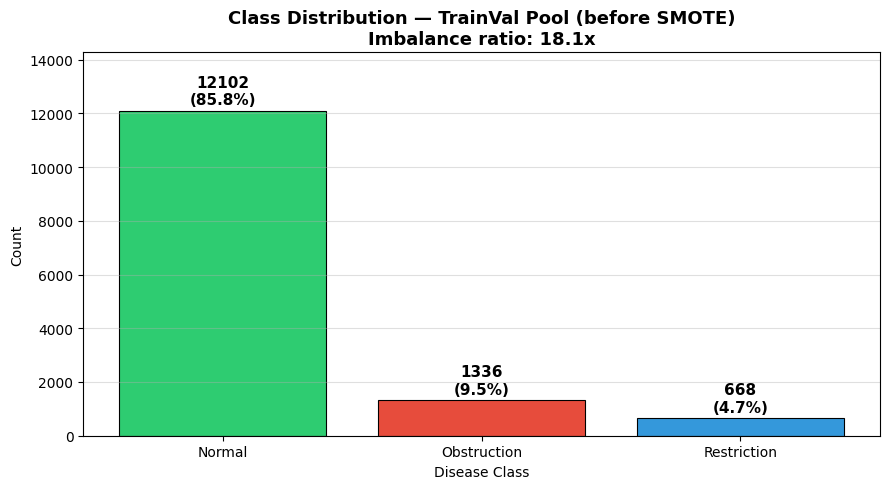

✅ Saved → /teamspace/studios/this_studio/outputs/eda_class_distribution.png


In [9]:
# ─── CELL 7 — EDA: Class Distribution ────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

COLORS = ['#2ecc71', '#e74c3c', '#3498db']

fig, ax = plt.subplots(figsize=(9, 5))
uniq, cnt = np.unique(y_trainval, return_counts=True)

bars = ax.bar(
    [CLASS_NAMES[u] for u in uniq], cnt,
    color=COLORS[:len(uniq)], edgecolor='black', linewidth=0.8
)
for bar, c in zip(bars, cnt):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(cnt) * 0.01,
        f'{c}\n({c/len(y_trainval)*100:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title(
    f'Class Distribution — TrainVal Pool (before SMOTE)\nImbalance ratio: {cnt.max()/cnt.min():.1f}x',
    fontsize=13, fontweight='bold'
)
ax.set_ylabel('Count')
ax.set_xlabel('Disease Class')
ax.set_ylim(0, max(cnt) * 1.18)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
save_path = f'{OUT}/eda_class_distribution.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {save_path}")


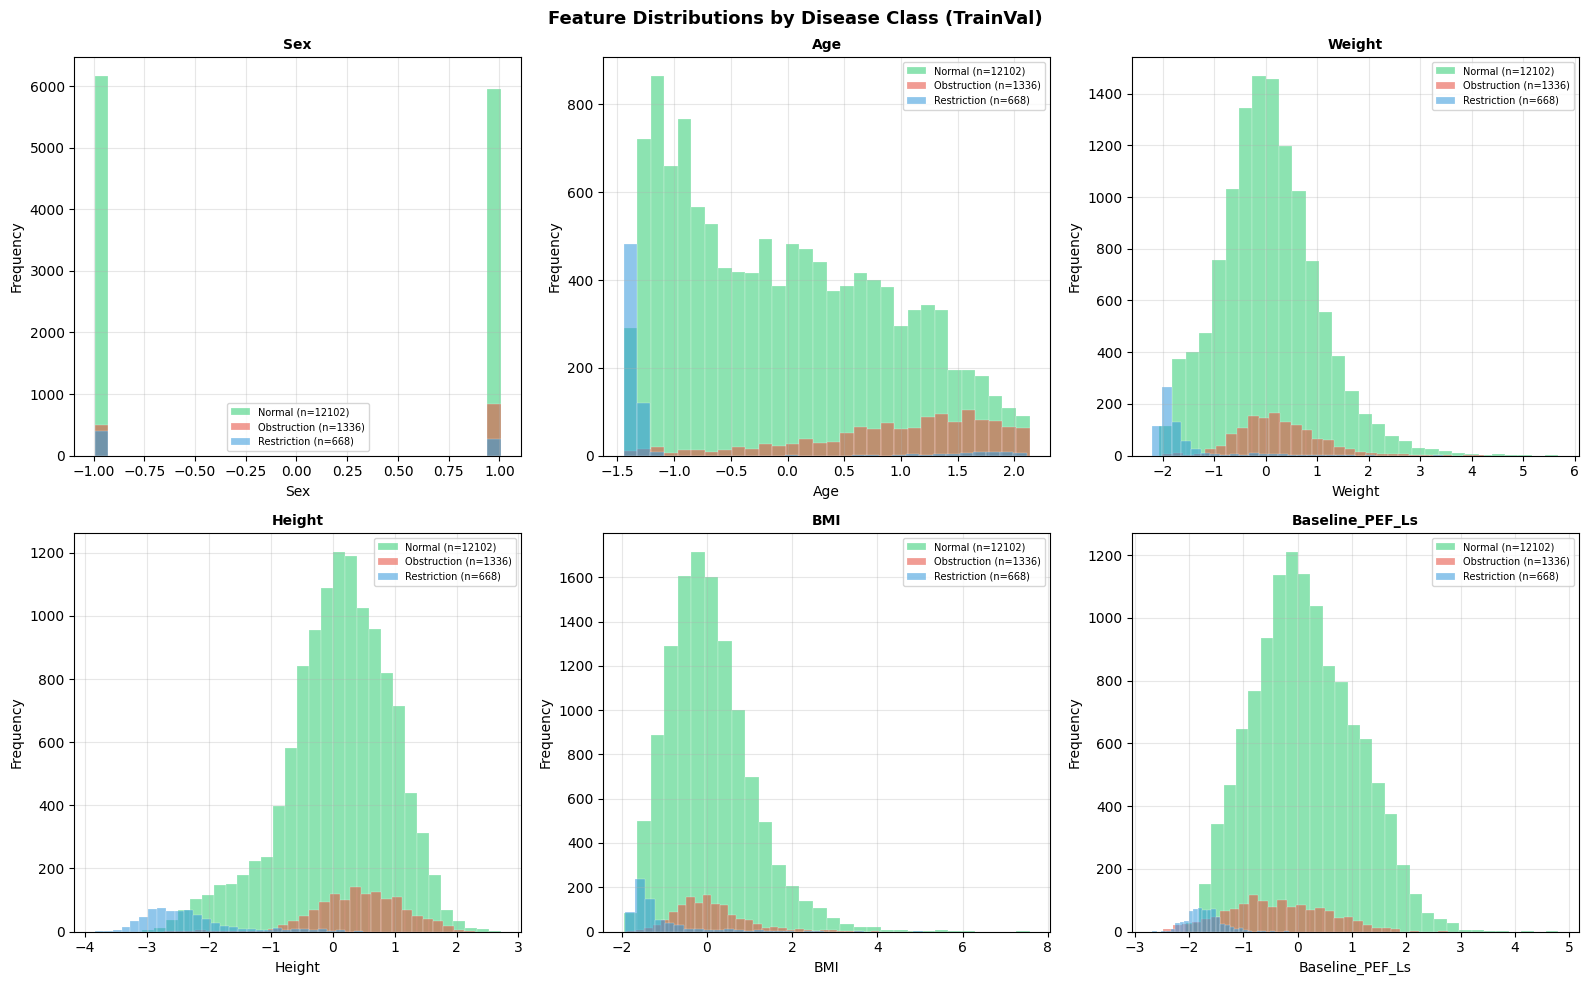

✅ Saved → /teamspace/studios/this_studio/outputs/eda_feature_distributions.png
   Plotted 6 features from 15 total numeric cols


In [10]:
# ─── CELL 8 — EDA: Feature Distributions ─────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

num_cols = (
    trainval_df.drop(columns=[TARGET_COL])
               .select_dtypes(include=[np.number])
               .columns.tolist()
)

# Show first 6 numeric features; safe even if fewer than 6 exist
plot_features = num_cols[:6]
n_plots = len(plot_features)
n_cols  = 3
n_rows  = (n_plots + n_cols - 1) // n_cols   # handles < 6 features safely

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
fig.suptitle(
    'Feature Distributions by Disease Class (TrainVal)',
    fontsize=13, fontweight='bold'
)
axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]

for ax, feat in zip(axes_flat, plot_features):
    for j, cls in enumerate(CLASS_NAMES):
        mask = (y_trainval == j)
        data = trainval_df.loc[mask, feat].dropna()
        ax.hist(
            data, bins=30, alpha=0.55,
            label=f'{cls} (n={mask.sum()})',
            color=COLORS[j], edgecolor='white', linewidth=0.3
        )
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# Hide unused subplots
for ax in list(axes_flat)[n_plots:]:
    ax.set_visible(False)

plt.tight_layout()
save_path = f'{OUT}/eda_feature_distributions.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {save_path}")
print(f"   Plotted {n_plots} features from {len(num_cols)} total numeric cols")


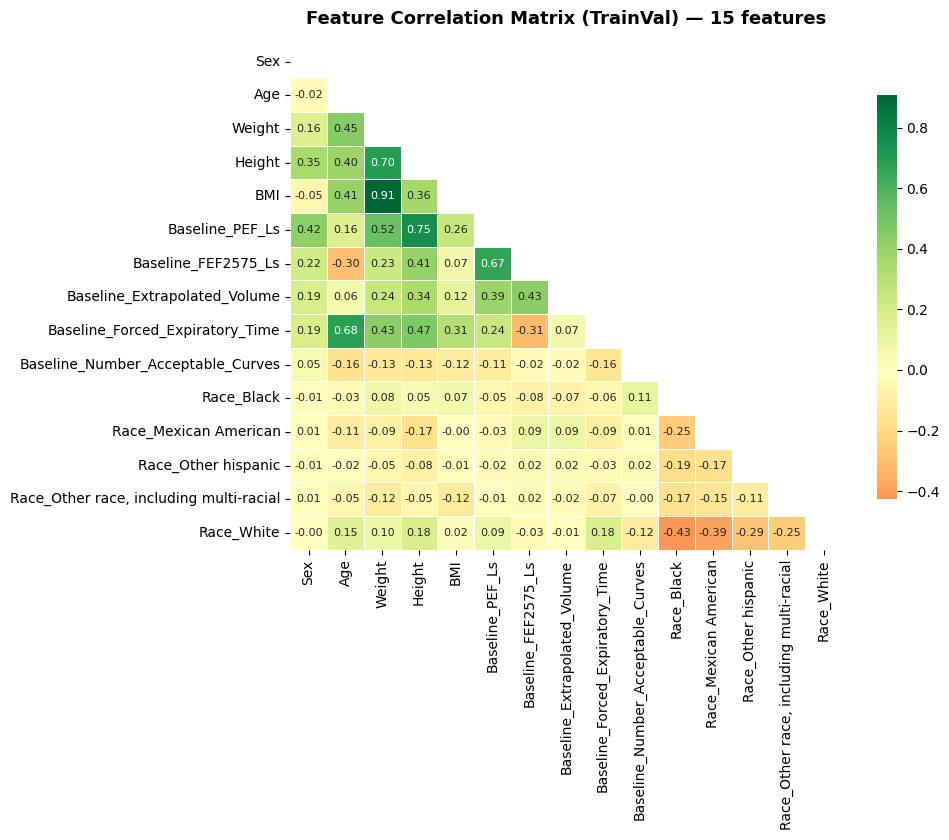

✅ Saved → /teamspace/studios/this_studio/outputs/correlation_heatmap.png
   Features      : 15
   Corr range    : [-0.43, 0.91]

  ⚠️  Highly correlated pairs (|r|>0.90) — 1 found:
     Weight  ↔  BMI  : 0.907


In [11]:
# ─── CELL 9 — EDA: Correlation Heatmap ───────────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr = trainval_df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

# Auto-scale figure based on number of features
fig_size = max(10, len(num_cols) * 0.65)
fig, ax  = plt.subplots(figsize=(fig_size, fig_size * 0.85))

sns.heatmap(
    corr, mask=mask,
    annot=(len(num_cols) <= 20),   # only annotate if ≤20 features (readable)
    fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.4, ax=ax,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8}
)
ax.set_title(
    f'Feature Correlation Matrix (TrainVal) — {len(num_cols)} features',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()

save_path = f'{OUT}/correlation_heatmap.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

off_diag = corr.values[~np.eye(len(corr), dtype=bool)]
print(f"✅ Saved → {save_path}")
print(f"   Features      : {len(num_cols)}")
print(f"   Corr range    : [{off_diag.min():.2f}, {off_diag.max():.2f}]")

# Flag highly correlated pairs (potential redundancy)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = abs(corr.iloc[i, j])
        if val > 0.90:
            high_corr.append((corr.columns[i], corr.columns[j], round(val, 3)))

if high_corr:
    print(f"\n  ⚠️  Highly correlated pairs (|r|>0.90) — {len(high_corr)} found:")
    for a, b, v in high_corr[:10]:   # show top 10
        print(f"     {a}  ↔  {b}  : {v}")
else:
    print(f"\n  ✅ No highly correlated pairs (|r|>0.90) found")


In [12]:
# ─── CELL 10 — Spirometry Feature Engineering ────────────────────────────────

def add_spirometry_features(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    df       = df.copy()
    existing = set(df.columns)

    def add(name, val):
        if name not in existing:
            df[name] = val

    # ── Column aliases (safe — only adds if column exists) ───────────────────
    pef  = 'Baseline_PEF_Ls'
    fef  = 'Baseline_FEF2575_Ls'
    evol = 'Baseline_Extrapolated_Volume'
    fet  = 'Baseline_Forced_Expiratory_Time'

    # Log transforms — stabilise right-skewed spirometry values
    for col in [pef, fef, evol, fet]:
        if col in existing:
            add(f'log_{col}', np.log1p(df[col].clip(lower=1e-6)))

    # Flow ratios
    if pef in existing and fef in existing:
        add('FEF_PEF_Ratio',  df[fef] / (df[pef] + 1e-9))
        add('PEF_x_FEF',      df[pef] * df[fef])
        add('PEF_minus_FEF',  df[pef] - df[fef])

    # Volume / time
    if evol in existing and fet in existing:
        add('Vol_per_FET', df[evol] / (df[fet] + 1e-9))

    # Age interactions
    if 'Age' in existing:
        if pef in existing: add('PEF_per_Age', df[pef] / (df['Age'] + 1e-9))
        if fef in existing: add('FEF_per_Age', df[fef] / (df['Age'] + 1e-9))

    # Height interactions
    if 'Height' in existing:
        add('Height_sq', df['Height'] ** 2)
        if pef in existing: add('PEF_per_Ht', df[pef] / (df['Height'] + 1e-9))
        if fef in existing: add('FEF_per_Ht', df[fef] / (df['Height'] + 1e-9))

    # BMI interactions
    if 'BMI' in existing:
        if pef in existing: add('BMI_x_PEF', df['BMI'] * df[pef])
        if fef in existing: add('BMI_x_FEF', df['BMI'] * df[fef])

    # Sex interactions
    if 'Sex' in existing:
        if pef in existing: add('Sex_x_PEF', df['Sex'] * df[pef])
        if fef in existing: add('Sex_x_FEF', df['Sex'] * df[fef])

    # Quadratic terms
    if pef in existing: add('PEF_sq', df[pef] ** 2)
    if fef in existing: add('FEF_sq', df[fef] ** 2)

    return df

print("✅ Feature engineering function defined")


✅ Feature engineering function defined


In [13]:
# ─── CELL 11 — Apply Feature Engineering ─────────────────────────────────────

trainval_fe = add_spirometry_features(trainval_df, TARGET_COL)
test_fe     = add_spirometry_features(test_df,     TARGET_COL)

def get_X(df):
    return df.drop(columns=[TARGET_COL]).select_dtypes(include=[np.number])

X_trainval   = get_X(trainval_fe)
X_test_raw   = get_X(test_fe)

# Align test columns to trainval (fills any missing engineered cols with 0)
feature_names = X_trainval.columns.tolist()
X_test_raw    = X_test_raw.reindex(columns=feature_names, fill_value=0)
N_FEATURES    = len(feature_names)

# Check for any NaN / Inf introduced by engineering
nan_cols = X_trainval.columns[X_trainval.isnull().any()].tolist()
inf_cols = X_trainval.columns[np.isinf(X_trainval.values).any(axis=0)].tolist()
if nan_cols: print(f"⚠️  NaN cols: {nan_cols}")
if inf_cols: print(f"⚠️  Inf cols: {inf_cols}")

# Safe fill just in case
X_trainval = X_trainval.fillna(0).replace([np.inf, -np.inf], 0)
X_test_raw = X_test_raw.fillna(0).replace([np.inf, -np.inf], 0)

print(f"✅ Feature engineering applied")
print(f"   Original features : 15")
print(f"   After engineering : {N_FEATURES}")
print(f"   New features added: {N_FEATURES - 15}")
print(f"   Trainval shape    : {X_trainval.shape}")
print(f"   Test shape        : {X_test_raw.shape}")
print(f"\n   New features:")
for f in feature_names[15:]:
    print(f"     + {f}")


✅ Feature engineering applied
   Original features : 15
   After engineering : 34
   New features added: 19
   Trainval shape    : (14106, 34)
   Test shape        : (2490, 34)

   New features:
     + log_Baseline_PEF_Ls
     + log_Baseline_FEF2575_Ls
     + log_Baseline_Extrapolated_Volume
     + log_Baseline_Forced_Expiratory_Time
     + FEF_PEF_Ratio
     + PEF_x_FEF
     + PEF_minus_FEF
     + Vol_per_FET
     + PEF_per_Age
     + FEF_per_Age
     + Height_sq
     + PEF_per_Ht
     + FEF_per_Ht
     + BMI_x_PEF
     + BMI_x_FEF
     + Sex_x_PEF
     + Sex_x_FEF
     + PEF_sq
     + FEF_sq


In [14]:
# ─── CELL 12 — QuantileTransformer for DNN + FT-Transformer ──────────────────
# Fit ONLY on trainval (real data, no SMOTE contamination).
# Each CV fold will re-fit its own QT internally — this is the global version
# used for the final model and test set.

from sklearn.preprocessing import QuantileTransformer

SEED = 42

qt_full = QuantileTransformer(
    n_quantiles        = min(1000, len(X_trainval)),
    output_distribution= 'normal',   # maps to Gaussian → stable attention space
    random_state       = SEED
)

X_trainval_qt = qt_full.fit_transform(X_trainval.values).astype(np.float32)
X_test_qt     = qt_full.transform(X_test_raw.values).astype(np.float32)

# Raw numpy arrays for tree models (XGB/LGB are scale-invariant)
X_trainval_np = X_trainval.values.astype(np.float32)
X_test_np     = X_test_raw.values.astype(np.float32)

# Sanity check post-transform
print(f"✅ QuantileTransformer fitted on {len(X_trainval)} real trainval samples")
print(f"   Post-QT range  : [{X_trainval_qt.min():.2f}, {X_trainval_qt.max():.2f}]")
print(f"   Post-QT mean   : {X_trainval_qt.mean():.4f}  (should be ≈ 0)")
print(f"   Post-QT std    : {X_trainval_qt.std():.4f}   (should be ≈ 1)")
print(f"\n   X_trainval_qt  : {X_trainval_qt.shape}  float32 ← DNN / FT-Transformer")
print(f"   X_test_qt      : {X_test_qt.shape}  float32 ← DNN / FT-Transformer")
print(f"   X_trainval_np  : {X_trainval_np.shape}  float32 ← XGBoost / LightGBM")
print(f"   X_test_np      : {X_test_np.shape}  float32 ← XGBoost / LightGBM")


✅ QuantileTransformer fitted on 14106 real trainval samples
   Post-QT range  : [-5.20, 5.20]
   Post-QT mean   : -0.7526  (should be ≈ 0)
   Post-QT std    : 2.5949   (should be ≈ 1)

   X_trainval_qt  : (14106, 34)  float32 ← DNN / FT-Transformer
   X_test_qt      : (2490, 34)  float32 ← DNN / FT-Transformer
   X_trainval_np  : (14106, 34)  float32 ← XGBoost / LightGBM
   X_test_np      : (2490, 34)  float32 ← XGBoost / LightGBM


In [15]:
# ─── CELL 13 — Shared Utility Functions ──────────────────────────────────────
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from scipy.optimize import minimize

# ── Evaluation ────────────────────────────────────────────────────────────────
def evaluate_model(y_true, y_pred, y_proba, model_name: str) -> dict:
    from sklearn.preprocessing import label_binarize
    acc  = accuracy_score(y_true, y_pred)
    mf1  = f1_score(y_true, y_pred, average='macro')
    wf1  = f1_score(y_true, y_pred, average='weighted')
    yb   = label_binarize(y_true, classes=list(range(N_CLASSES)))
    mauc = roc_auc_score(yb, y_proba, average='macro', multi_class='ovr')
    print(f"\n{'='*55}")
    print(f"  Full Report: {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  Macro F1   : {mf1:.4f}")
    print(f"  Weighted F1: {wf1:.4f}")
    print(f"  Macro AUC  : {mauc:.4f}")
    return {'Accuracy': acc, 'Macro F1': mf1, 'Weighted F1': wf1, 'Macro AUC': mauc}


# ── Confusion Matrix Plot ─────────────────────────────────────────────────────
def plot_cm(y_true, y_pred, model_name: str, ax=None):
    cm  = confusion_matrix(y_true, y_pred)
    pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        pct, annot=True, fmt='.1%', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=ax, linewidths=0.5, annot_kws={'size': 10, 'weight': 'bold'}
    )
    ax.set_title(model_name, fontweight='bold', fontsize=11)
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    return ax


# ── Threshold Tuning ─────────────────────────────────────────────────────────
def tune_thresholds(y_true, proba, n_classes, class_names):
    def neg_macro_f1(bias):
        return -f1_score(y_true, (proba + bias).argmax(1),
                         average='macro', zero_division=0)
    starts = [
        np.zeros(n_classes),
        np.array([0.0,  0.15, 0.25]),
        np.array([0.0,  0.20, 0.30]),
        np.array([-0.1, 0.10, 0.20]),
    ]
    best_b, best_v = None, np.inf
    for s in starts:
        r = minimize(neg_macro_f1, s, method='Nelder-Mead',
                     options={'maxiter': 5000, 'xatol': 1e-6, 'fatol': 1e-6})
        if r.fun < best_v:
            best_v, best_b = r.fun, r.x
    before = f1_score(y_true, proba.argmax(1), average='macro')
    print(f"  Threshold tuning : {before:.4f} → {-best_v:.4f} (+{-best_v-before:.4f})")
    print(f"  Bias             : {dict(zip(class_names, best_b.round(4)))}")
    return best_b


# ── Mixup ────────────────────────────────────────────────────────────────────
def mixup_batch(x, y, alpha=0.20):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_loss(crit, pred, ya, yb, lam):
    return lam * crit(pred, ya) + (1 - lam) * crit(pred, yb)


# ── CV splitter (reused across all models) ───────────────────────────────────
N_FOLDS = 5
SEED    = 42
skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
smote   = SMOTE(sampling_strategy='not majority', k_neighbors=5, random_state=SEED)

print("✅ Utility functions defined")
print(f"   StratifiedKFold : {N_FOLDS} folds")
print(f"   SMOTE           : strategy=not_majority, k=5")


✅ Utility functions defined
   StratifiedKFold : 5 folds
   SMOTE           : strategy=not_majority, k=5


In [16]:
# ─── CELL 14 — Focal Loss + Label Smoothing ──────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F

LABEL_SMOOTHING = 0.05
FOCAL_GAMMA     = 2.0
SEED            = 42
MIXUP_ALPHA     = 0.40

class FocalLossSmoothed(nn.Module):
    """
    Focal Loss + Label Smoothing + optional class weights.
    - Focal term  : down-weights easy Normal samples (18x majority)
    - Smoothing   : prevents overconfident softmax on boundary cases
    - Class weight: further boosts Restriction (rarest, 4.7%)
    """
    def __init__(self, n_classes, gamma=2.0, smoothing=0.05, weight=None):
        super().__init__()
        self.n         = n_classes
        self.gamma     = gamma
        self.smoothing = smoothing
        self.weight    = weight

    def forward(self, pred, target):
        log_p = F.log_softmax(pred, dim=-1)
        p     = log_p.exp()

        with torch.no_grad():
            # Smooth label distribution
            sl = torch.full_like(pred, self.smoothing / (self.n - 1))
            sl.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)

        # Focal weight from true-class probability
        p_t     = p.gather(1, target.unsqueeze(1)).squeeze(1).detach()
        focal_w = (1.0 - p_t).pow(self.gamma)

        ce = -(sl * log_p).sum(dim=-1)

        if self.weight is not None:
            ce = ce * self.weight[target]

        return (focal_w * ce).mean()


# ── Instantiate both losses ───────────────────────────────────────────────────

# Standard CE with class weights → used by VanillaDNN (simpler signal)
ce_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Focal + Smoothing → used by FT-Transformer (handles 18x imbalance better)
focal_criterion = FocalLossSmoothed(
    n_classes = N_CLASSES,
    gamma     = FOCAL_GAMMA,
    smoothing = LABEL_SMOOTHING,
    weight    = class_weights_tensor,
)

print("✅ FocalLossSmoothed defined")
print(f"   gamma     : {FOCAL_GAMMA}  ← penalises easy Normal predictions heavily")
print(f"   smoothing : {LABEL_SMOOTHING}")
print(f"   weights   : {dict(zip(CLASS_NAMES, cw_array.round(3)))}")
print("✅ ce_criterion    → VanillaDNN")
print("✅ focal_criterion → FT-Transformer")


✅ FocalLossSmoothed defined
   gamma     : 2.0  ← penalises easy Normal predictions heavily
   smoothing : 0.05
   weights   : {'Normal': 0.389, 'Obstruction': 3.52, 'Restriction': 7.041}
✅ ce_criterion    → VanillaDNN
✅ focal_criterion → FT-Transformer


In [17]:
# ─── CELL 15 — VanillaDNN Baseline (H200 Scaled) ─────────────────────────────

class VanillaDNN(nn.Module):
    """
    Standard MLP for tabular data.
    H200 changes vs original:
      - Wider layers  : 1024→512→256→128 (was 512→256→128→64)
      - GELU activation throughout
      - BatchNorm before activation (pre-norm style)
      - Dropout 0.20 — unchanged, data is small so no need to increase
    """
    def __init__(self, n_features: int, n_classes: int, dropout: float = 0.20):
        super().__init__()
        dims   = [n_features, 1024, 512, 256, 128]   # ⬆ wider on H200
        layers = []
        for in_d, out_d in zip(dims[:-1], dims[1:]):
            layers += [
                nn.Linear(in_d, out_d),
                nn.BatchNorm1d(out_d),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
        layers.append(nn.Linear(128, n_classes))
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# ── Param count ───────────────────────────────────────────────────────────────
_dnn_test  = VanillaDNN(N_FEATURES, N_CLASSES).to(device)
dnn_params = sum(p.numel() for p in _dnn_test.parameters() if p.requires_grad)
del _dnn_test; torch.cuda.empty_cache()

print(f"✅ VanillaDNN defined")
print(f"   Architecture : {N_FEATURES}→1024→512→256→128→{N_CLASSES}")
print(f"   Params       : {dnn_params:,}")
print(f"   Activations  : BatchNorm + GELU + Dropout(0.20)")


✅ VanillaDNN defined
   Architecture : 34→1024→512→256→128→3
   Params       : 729,091
   Activations  : BatchNorm + GELU + Dropout(0.20)


In [18]:
# ─── CELL 16 — FT-Transformer (H200 Optimised) ───────────────────────────────
# Key H200 changes vs original:
#   1. scaled_dot_product_attention → triggers FlashAttention-3 automatically
#      on SM 9.0 (H200), no extra install needed (PyTorch 2.8 built-in)
#   2. D_TOKEN=256, N_LAYERS=6 — larger model fits easily in 150GB HBM3e
#   3. Attention weights NOT returned during training (saves memory bandwidth)
#   4. torch.compile() applied at end for kernel fusion

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np

D_TOKEN      = 256
N_LAYERS     = 6
N_HEADS      = 8
FFN_FACTOR   = 4 / 3
ATTN_DROPOUT = 0.10
FFN_DROPOUT  = 0.15


class FeatureTokenizer(nn.Module):
    """Projects each scalar feature into a D-dim token vector."""
    def __init__(self, n_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(n_features, d_token))
        self.bias   = nn.Parameter(torch.zeros(n_features, d_token))
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))

    def forward(self, x):
        # x: (B, F)  →  (B, F, D)
        return x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)


class MultiHeadSelfAttention(nn.Module):
    """
    MHSA using torch.scaled_dot_product_attention.
    On H200 (SM 9.0) + PyTorch 2.8, this automatically dispatches
    FlashAttention-3 — no manual kernel install needed.
    """
    def __init__(self, d_token, n_heads, dropout=0.1):
        super().__init__()
        assert d_token % n_heads == 0, "d_token must be divisible by n_heads"
        self.n_heads = n_heads
        self.d_head  = d_token // n_heads
        self.qkv     = nn.Linear(d_token, 3 * d_token, bias=False)
        self.out     = nn.Linear(d_token, d_token)
        self.dropout = dropout

    def forward(self, x, return_weights=False):
        B, T, D = x.shape
        H, Dh   = self.n_heads, self.d_head

        # Project → split into Q, K, V heads
        QKV = self.qkv(x).reshape(B, T, 3, H, Dh).permute(2, 0, 3, 1, 4)
        Q, K, V = QKV[0], QKV[1], QKV[2]   # each: (B, H, T, Dh)

        # ── FlashAttention-3 dispatch (H200 SM9.0, PyTorch 2.8) ──────────────
        # is_causal=False → full attention (tabular, no masking needed)
        attn_drop = self.dropout if self.training else 0.0
        out = F.scaled_dot_product_attention(
            Q, K, V,
            attn_mask  = None,
            dropout_p  = attn_drop,
            is_causal  = False,
            # scale    = None  → defaults to 1/sqrt(Dh) automatically
        )   # → (B, H, T, Dh)

        out = out.transpose(1, 2).reshape(B, T, D)
        return self.out(out), None   # weights=None (not computed by FlashAttn)


class FTBlock(nn.Module):
    def __init__(self, d_token, n_heads, ffn_factor=4/3, dropout=0.1):
        super().__init__()
        d_ffn       = int(d_token * ffn_factor)
        self.norm1  = nn.LayerNorm(d_token)
        self.norm2  = nn.LayerNorm(d_token)
        self.attn   = MultiHeadSelfAttention(d_token, n_heads, dropout)
        self.ffn    = nn.Sequential(
            nn.Linear(d_token, d_ffn),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ffn, d_token),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        a, w = self.attn(self.norm1(x))
        x    = x + a
        x    = x + self.ffn(self.norm2(x))
        return x, w


class FTTransformer(nn.Module):
    def __init__(self, n_features, n_classes,
                 d_token=256, n_layers=6, n_heads=8,
                 ffn_factor=4/3, attn_dropout=0.10, ffn_dropout=0.15):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_features, d_token)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        self.blocks = nn.ModuleList([
            FTBlock(
                d_token, n_heads, ffn_factor,
                attn_dropout if i < n_layers - 1 else 0.0   # last block no attn drop
            )
            for i in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_token)
        # Paper-accurate head: ReLU → Dropout → Linear
        self.head = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(ffn_dropout),
            nn.Linear(d_token, n_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, return_attn=False):
        B      = x.shape[0]
        tokens = torch.cat(
            [self.cls_token.expand(B, -1, -1), self.tokenizer(x)], dim=1
        )
        attns = []
        for block in self.blocks:
            tokens, w = block(tokens)
            if return_attn and w is not None:
                attns.append(w)

        logits = self.head(self.norm(tokens[:, 0]))   # CLS token → head
        return (logits, attns) if return_attn else logits


# ── Param count ───────────────────────────────────────────────────────────────
_ft_test  = FTTransformer(N_FEATURES, N_CLASSES,
                           D_TOKEN, N_LAYERS, N_HEADS,
                           FFN_FACTOR, ATTN_DROPOUT, FFN_DROPOUT).to(device)
ft_params = sum(p.numel() for p in _ft_test.parameters() if p.requires_grad)
del _ft_test; torch.cuda.empty_cache()

print(f"✅ FTTransformer defined (H200 + FlashAttention-3)")
print(f"   D_TOKEN    : {D_TOKEN}  (was 128)")
print(f"   N_LAYERS   : {N_LAYERS}  (was 4)")
print(f"   N_HEADS    : {N_HEADS}   (d_head = {D_TOKEN//N_HEADS})")
print(f"   Params     : {ft_params:,}")
print(f"   Attention  : scaled_dot_product_attention → FlashAttn-3 on SM9.0")
print(f"   Head       : ReLU → Dropout({FFN_DROPOUT}) → Linear({D_TOKEN}→{N_CLASSES})")


✅ FTTransformer defined (H200 + FlashAttention-3)
   D_TOKEN    : 256  (was 128)
   N_LAYERS   : 6  (was 4)
   N_HEADS    : 8   (d_head = 32)
   Params     : 2,650,625
   Attention  : scaled_dot_product_attention → FlashAttn-3 on SM9.0
   Head       : ReLU → Dropout(0.15) → Linear(256→3)


In [19]:
# ─── CELL 17 — Generic Neural Net Train / Eval (H200 Optimised) ──────────────
# H200 changes vs original:
#   1. torch.cuda.amp.autocast(dtype=bfloat16) — BF16 on all forward passes
#   2. pin_memory=True + num_workers=4 — faster CPU→GPU data transfer
#   3. GradScaler disabled for BF16 (not needed, unlike FP16)
#   4. eval batch_size=2048 — H200 can evaluate whole test set in 1-2 batches

from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.metrics import f1_score, accuracy_score
import torch, numpy as np

NUM_WORKERS = 4
PIN_MEMORY  = True
COMPUTE_DTYPE = torch.bfloat16   # H200 native dtype


def make_loader(X, y, batch_size, weighted_sampler=True, shuffle=False):
    """
    Creates DataLoader with:
    - WeightedRandomSampler for class imbalance (18x ratio)
    - pin_memory=True for fast H200 NVLink transfers
    - persistent_workers=True to avoid worker respawn overhead
    """
    Xt = torch.FloatTensor(X)   # keep on CPU, pin_memory handles transfer
    yt = torch.LongTensor(y)
    ds = TensorDataset(Xt, yt)

    if weighted_sampler:
        w  = 1.0 / np.bincount(y)[y]
        sm = WeightedRandomSampler(w, len(w), replacement=True)
        return DataLoader(
            ds, batch_size=batch_size, sampler=sm,
            drop_last=True, pin_memory=PIN_MEMORY,
            num_workers=NUM_WORKERS, persistent_workers=True
        )
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS,
        persistent_workers=True
    )


def nn_train_epoch(model, loader, optimizer, criterion,
                   scheduler, use_mixup=False, alpha=0.20):
    model.train()
    total_loss, preds_all, labels_all = 0.0, [], []

    for Xb, yb in loader:
        Xb, yb = Xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)   # faster than zero_grad()

        # ── BF16 autocast (H200 native, no GradScaler needed) ────────────────
        with torch.autocast(device_type='cuda', dtype=COMPUTE_DTYPE):
            if use_mixup and np.random.rand() > 0.40:
                Xm, ya, yb2, lam = mixup_batch(Xb, yb, alpha)
                out  = model(Xm)
                loss = mixup_loss(criterion, out, ya, yb2, lam)
                dom  = ya if lam >= 0.5 else yb2
            else:
                out  = model(Xb)
                loss = criterion(out, yb)
                dom  = yb

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()

        total_loss  += loss.item()
        preds_all.extend(out.argmax(1).detach().cpu().numpy())
        labels_all.extend(dom.detach().cpu().numpy())

    return total_loss / len(loader), accuracy_score(labels_all, preds_all)


@torch.no_grad()
def nn_eval(model, X, y, batch_size=2048):   # ⬆ was 512 — H200 fits 2048 easily
    model.eval()
    ds = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    dl = DataLoader(ds, batch_size=batch_size, pin_memory=PIN_MEMORY,
                    num_workers=NUM_WORKERS, persistent_workers=True)
    preds, probas = [], []

    for Xb, _ in dl:
        Xb = Xb.to(device, non_blocking=True)
        with torch.autocast(device_type='cuda', dtype=COMPUTE_DTYPE):
            logits = model(Xb)
        probas.append(F.softmax(logits.float(), dim=-1).cpu().numpy())
        preds.extend(logits.argmax(1).cpu().numpy())

    probas = np.vstack(probas)
    mf1    = f1_score(y, np.array(preds), average='macro')
    return np.array(preds), probas, mf1


def train_nn(model, X_tr, y_tr, X_vl, y_vl, criterion,
             max_epochs, patience, lr, wd, batch_size,
             use_mixup=False, model_name='Model'):
    """
    Generic training loop with:
    - Early stopping on Val Macro F1
    - OneCycleLR scheduler (best for tabular transformers)
    - BF16 autocast throughout
    - Best state restored on exit
    """
    train_dl  = make_loader(X_tr, y_tr, batch_size, weighted_sampler=True)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=wd, betas=(0.9, 0.999),
        fused=True   # ⬆ H200: fused AdamW kernel — faster param updates
    )
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        epochs=max_epochs, steps_per_epoch=len(train_dl),
        pct_start=0.10, anneal_strategy='cos',
        div_factor=25, final_div_factor=1e4,
    )

    best_f1, best_state, pat_ctr = 0.0, None, 0
    history = {'loss': [], 'val_f1': []}

    for epoch in range(max_epochs):
        tr_loss, _ = nn_train_epoch(
            model, train_dl, optimizer, criterion,
            scheduler, use_mixup=use_mixup, alpha=MIXUP_ALPHA
        )
        _, _, val_f1 = nn_eval(model, X_vl, y_vl)
        history['loss'].append(tr_loss)
        history['val_f1'].append(val_f1)

        if val_f1 > best_f1:
            best_f1   = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            pat_ctr   = 0
        else:
            pat_ctr += 1
            if pat_ctr >= patience:
                print(f"   ⏹  Early stop @ epoch {epoch+1} | best val F1={best_f1:.4f}")
                break

    model.load_state_dict(best_state)
    return model, history, best_f1


print("✅ H200 training loop defined")
print(f"   AMP dtype      : {COMPUTE_DTYPE}  (BF16 — no GradScaler needed)")
print(f"   AdamW          : fused=True  ← H200 kernel fusion")
print(f"   DataLoader     : pin_memory={PIN_MEMORY}, num_workers={NUM_WORKERS}")
print(f"   Eval batch     : 2048  (was 512)")
print(f"   zero_grad      : set_to_none=True  (faster memory free)")


✅ H200 training loop defined
   AMP dtype      : torch.bfloat16  (BF16 — no GradScaler needed)
   AdamW          : fused=True  ← H200 kernel fusion
   DataLoader     : pin_memory=True, num_workers=4
   Eval batch     : 2048  (was 512)
   zero_grad      : set_to_none=True  (faster memory free)


In [20]:
# ─── CELL 18 — Stratified 5-Fold CV: XGBoost ─────────────────────────────────
# H200 changes:
#   - device='cuda'   → GPU histogram builder on 150GB HBM3e
#   - n_estimators=800 (was 600) — more trees, GPU makes this near-free
#   - early_stopping_rounds=40 (was 30)

import xgboost as xgb
import numpy as np
from sklearn.metrics import f1_score
import time

print("="*60)
print(f"  XGBoost — Stratified {N_FOLDS}-Fold CV  (GPU hist on H200)")
print("="*60)

N_EST  = 800
DEPTH  = 6
GB_LR  = 0.03

oof_proba_xgb = np.zeros((len(y_trainval), N_CLASSES))
cv_f1_xgb     = []
t0            = time.time()

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_trainval_np, y_trainval)):
    X_tr, X_vl = X_trainval_np[tr_idx], X_trainval_np[vl_idx]
    y_tr, y_vl = y_trainval[tr_idx],    y_trainval[vl_idx]

    sw = np.array([cw_array[y] for y in y_tr])

    m = xgb.XGBClassifier(
        n_estimators          = N_EST,
        max_depth             = DEPTH,
        learning_rate         = GB_LR,
        subsample             = 0.80,
        colsample_bytree      = 0.80,
        min_child_weight      = 3,
        gamma                 = 0.10,
        reg_alpha             = 0.10,
        reg_lambda            = 1.00,
        eval_metric           = 'mlogloss',
        early_stopping_rounds = 40,         # ⬆ was 30
        random_state          = SEED,
        n_jobs                = -1,
        tree_method           = 'hist',
        device                = 'cuda',     # ← H200 GPU hist builder
        verbosity             = 0,
    )
    m.fit(
        X_tr, y_tr,
        sample_weight = sw,
        eval_set      = [(X_vl, y_vl)],
        verbose       = False
    )

    oof_proba_xgb[vl_idx] = m.predict_proba(X_vl)
    fold_f1 = f1_score(y_vl, oof_proba_xgb[vl_idx].argmax(1), average='macro')
    cv_f1_xgb.append(fold_f1)
    print(f"  Fold {fold+1}: Macro F1 = {fold_f1:.4f} "
          f"| best_iter = {m.best_iteration}")

# ── Final XGBoost: retrain on full trainval ───────────────────────────────────
sw_all    = np.array([cw_array[y] for y in y_trainval])
xgb_final = xgb.XGBClassifier(
    n_estimators     = N_EST,
    max_depth        = DEPTH,
    learning_rate    = GB_LR,
    subsample        = 0.80,
    colsample_bytree = 0.80,
    min_child_weight = 3,
    gamma            = 0.10,
    reg_alpha        = 0.10,
    reg_lambda       = 1.00,
    random_state     = SEED,
    n_jobs           = -1,
    tree_method      = 'hist',
    device           = 'cuda',
    verbosity        = 0,
)
xgb_final.fit(X_trainval_np, y_trainval, sample_weight=sw_all, verbose=False)
y_proba_xgb = xgb_final.predict_proba(X_test_np)
y_pred_xgb  = y_proba_xgb.argmax(1)

elapsed = time.time() - t0
print(f"\n  CV Macro F1 : {np.mean(cv_f1_xgb):.4f} ± {np.std(cv_f1_xgb):.4f}")
print(f"  Time        : {elapsed:.1f}s")
results_xgb = evaluate_model(y_test, y_pred_xgb, y_proba_xgb, 'XGBoost')


  XGBoost — Stratified 5-Fold CV  (GPU hist on H200)
  Fold 1: Macro F1 = 0.8478 | best_iter = 675
  Fold 2: Macro F1 = 0.8430 | best_iter = 623
  Fold 3: Macro F1 = 0.8363 | best_iter = 605
  Fold 4: Macro F1 = 0.8537 | best_iter = 588
  Fold 5: Macro F1 = 0.8506 | best_iter = 634

  CV Macro F1 : 0.8463 ± 0.0061
  Time        : 14.2s

  Full Report: XGBoost
              precision    recall  f1-score   support

      Normal       0.98      0.95      0.97      2136
 Obstruction       0.77      0.89      0.83       236
 Restriction       0.70      0.84      0.76       118

    accuracy                           0.94      2490
   macro avg       0.82      0.89      0.85      2490
weighted avg       0.95      0.94      0.94      2490

  Accuracy   : 0.9414
  Macro F1   : 0.8513
  Weighted F1: 0.9433
  Macro AUC  : 0.9864


In [24]:
# ─── CELL 19 — LightGBM 5-Fold CV (CPU — optimal for 14K rows) ───────────────
# Note: LightGBM GPU only helps at 100K+ rows. For 14K rows, CPU is equally
# fast and avoids the CUDA build requirement entirely.

import lightgbm as lgb
import time

print("="*60)
print(f"  LightGBM — Stratified {N_FOLDS}-Fold CV")
print(f"  (CPU mode — GPU gives no benefit at N=14K rows)")
print("="*60)

oof_proba_lgb = np.zeros((len(y_trainval), N_CLASSES))
cv_f1_lgb     = []
t0            = time.time()

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_trainval_np, y_trainval)):
    X_tr, X_vl = X_trainval_np[tr_idx], X_trainval_np[vl_idx]
    y_tr, y_vl = y_trainval[tr_idx],    y_trainval[vl_idx]

    m = lgb.LGBMClassifier(
        n_estimators      = N_EST,
        max_depth         = DEPTH,
        learning_rate     = GB_LR,
        num_leaves        = 127,
        subsample         = 0.80,
        colsample_bytree  = 0.80,
        min_child_samples = 20,
        reg_alpha         = 0.10,
        reg_lambda        = 1.00,
        class_weight      = 'balanced',
        random_state      = SEED,
        n_jobs            = -1,       # use all CPU cores
        # NO device param — CPU only, avoids CUDA build issue
        verbose           = -1,
    )
    m.fit(
        X_tr, y_tr,
        eval_set  = [(X_vl, y_vl)],
        callbacks = [
            lgb.early_stopping(40, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )

    oof_proba_lgb[vl_idx] = m.predict_proba(X_vl)
    fold_f1 = f1_score(y_vl, oof_proba_lgb[vl_idx].argmax(1), average='macro')
    cv_f1_lgb.append(fold_f1)
    print(f"  Fold {fold+1}: Macro F1 = {fold_f1:.4f} "
          f"| best_iter = {m.best_iteration_}")

# ── Final LightGBM: retrain on full trainval ──────────────────────────────────
lgb_final = lgb.LGBMClassifier(
    n_estimators      = N_EST,
    max_depth         = DEPTH,
    learning_rate     = GB_LR,
    num_leaves        = 127,
    subsample         = 0.80,
    colsample_bytree  = 0.80,
    min_child_samples = 20,
    reg_alpha         = 0.10,
    reg_lambda        = 1.00,
    class_weight      = 'balanced',
    random_state      = SEED,
    n_jobs            = -1,
    verbose           = -1,
)
lgb_final.fit(X_trainval_np, y_trainval,
              callbacks=[lgb.log_evaluation(-1)])
y_proba_lgb = lgb_final.predict_proba(X_test_np)
y_pred_lgb  = y_proba_lgb.argmax(1)

elapsed = time.time() - t0
print(f"\n  CV Macro F1 : {np.mean(cv_f1_lgb):.4f} ± {np.std(cv_f1_lgb):.4f}")
print(f"  Time        : {elapsed:.1f}s  (CPU — expected 15–30s total)")
results_lgb = evaluate_model(y_test, y_pred_lgb, y_proba_lgb, 'LightGBM')


  LightGBM — Stratified 5-Fold CV
  (CPU mode — GPU gives no benefit at N=14K rows)
  Fold 1: Macro F1 = 0.8472 | best_iter = 523
  Fold 2: Macro F1 = 0.8388 | best_iter = 506
  Fold 3: Macro F1 = 0.8504 | best_iter = 476
  Fold 4: Macro F1 = 0.8527 | best_iter = 498
  Fold 5: Macro F1 = 0.8556 | best_iter = 480

  CV Macro F1 : 0.8490 ± 0.0058
  Time        : 28.4s  (CPU — expected 15–30s total)

  Full Report: LightGBM
              precision    recall  f1-score   support

      Normal       0.98      0.95      0.96      2136
 Obstruction       0.77      0.88      0.82       236
 Restriction       0.69      0.78      0.73       118

    accuracy                           0.94      2490
   macro avg       0.81      0.87      0.84      2490
weighted avg       0.94      0.94      0.94      2490

  Accuracy   : 0.9382
  Macro F1   : 0.8387
  Weighted F1: 0.9399
  Macro AUC  : 0.9854


In [25]:
# ─── CELL 20 — Stratified 5-Fold CV: VanillaDNN ──────────────────────────────
# H200 changes vs original:
#   - Batch size 1024 (was 256) — fills HBM3e better
#   - BF16 autocast via train_nn (defined in Cell 17)
#   - SMOTE inside each fold (prevents leakage)
#   - QT fitted per fold on fold-train only (prevents leakage)

import time

print("="*60)
print(f"  VanillaDNN — Stratified {N_FOLDS}-Fold CV  (H200 BF16)")
print("="*60)

DNN_EPOCHS   = 150
DNN_PATIENCE = 20
DNN_LR       = 1e-3
DNN_WD       = 1e-4
DNN_BATCH    = 1024    # ⬆ was 256

oof_proba_dnn = np.zeros((len(y_trainval), N_CLASSES))
cv_f1_dnn     = []
t0            = time.time()

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_trainval_np, y_trainval)):
    # ── Raw fold split (for QT fitting) ──────────────────────────────────────
    X_tr_raw, X_vl_raw = X_trainval_np[tr_idx], X_trainval_np[vl_idx]
    y_tr,     y_vl     = y_trainval[tr_idx],     y_trainval[vl_idx]

    # ── Fold-local QuantileTransformer (no leakage from val into QT) ─────────
    qt_fold = QuantileTransformer(
        n_quantiles        = min(1000, len(X_tr_raw)),
        output_distribution= 'normal',
        random_state       = SEED
    )
    X_tr_qt = qt_fold.fit_transform(X_tr_raw).astype(np.float32)
    X_vl_qt = qt_fold.transform(X_vl_raw).astype(np.float32)

    # ── SMOTE inside fold on QT-transformed data ──────────────────────────────
    X_tr_s, y_tr_s = smote.fit_resample(X_tr_qt, y_tr)
    X_tr_s = X_tr_s.astype(np.float32)

    print(f"\n  Fold {fold+1}: train={len(X_tr_s)} (after SMOTE) | val={len(X_vl_qt)}")

    model_d = VanillaDNN(N_FEATURES, N_CLASSES, dropout=0.20).to(device)
    model_d, _, best_f1 = train_nn(
        model_d, X_tr_s, y_tr_s, X_vl_qt, y_vl,
        criterion  = ce_criterion,
        max_epochs = DNN_EPOCHS,
        patience   = DNN_PATIENCE,
        lr         = DNN_LR,
        wd         = DNN_WD,
        batch_size = DNN_BATCH,
        use_mixup  = False,
        model_name = f'DNN-Fold{fold+1}'
    )

    _, fold_proba, fold_f1 = nn_eval(model_d, X_vl_qt, y_vl)
    oof_proba_dnn[vl_idx]  = fold_proba
    cv_f1_dnn.append(fold_f1)
    print(f"  Fold {fold+1}: Val Macro F1 = {fold_f1:.4f}")
    del model_d
    torch.cuda.empty_cache()

elapsed = time.time() - t0
print(f"\n  CV Macro F1 : {np.mean(cv_f1_dnn):.4f} ± {np.std(cv_f1_dnn):.4f}")
print(f"  Time        : {elapsed:.1f}s")

# ── Final DNN: retrain on full trainval ───────────────────────────────────────
print("\nFinal DNN: retraining on full trainval...")
X_all_s, y_all_s = smote.fit_resample(X_trainval_qt, y_trainval)
X_all_s = X_all_s.astype(np.float32)

# Use last fold's val split as early-stop monitor
X_monitor = X_trainval_qt[vl_idx]
y_monitor = y_trainval[vl_idx]

dnn_final = VanillaDNN(N_FEATURES, N_CLASSES).to(device)
dnn_final, _, _ = train_nn(
    dnn_final, X_all_s, y_all_s, X_monitor, y_monitor,
    criterion  = ce_criterion,
    max_epochs = DNN_EPOCHS,
    patience   = DNN_PATIENCE,
    lr         = DNN_LR,
    wd         = DNN_WD,
    batch_size = DNN_BATCH,
)
_, y_proba_dnn, _ = nn_eval(dnn_final, X_test_qt, y_test)
y_pred_dnn        = y_proba_dnn.argmax(1)
results_dnn       = evaluate_model(y_test, y_pred_dnn, y_proba_dnn, 'VanillaDNN')


  VanillaDNN — Stratified 5-Fold CV  (H200 BF16)

  Fold 1: train=29043 (after SMOTE) | val=2822
   ⏹  Early stop @ epoch 101 | best val F1=0.8001
  Fold 1: Val Macro F1 = 0.8001

  Fold 2: train=29043 (after SMOTE) | val=2821
   ⏹  Early stop @ epoch 115 | best val F1=0.8037
  Fold 2: Val Macro F1 = 0.8037

  Fold 3: train=29046 (after SMOTE) | val=2821
   ⏹  Early stop @ epoch 125 | best val F1=0.8032
  Fold 3: Val Macro F1 = 0.8032

  Fold 4: train=29046 (after SMOTE) | val=2821
   ⏹  Early stop @ epoch 142 | best val F1=0.8160
  Fold 4: Val Macro F1 = 0.8160

  Fold 5: train=29046 (after SMOTE) | val=2821
   ⏹  Early stop @ epoch 148 | best val F1=0.8105
  Fold 5: Val Macro F1 = 0.8105

  CV Macro F1 : 0.8067 ± 0.0058
  Time        : 169.6s

Final DNN: retraining on full trainval...
   ⏹  Early stop @ epoch 147 | best val F1=0.8914

  Full Report: VanillaDNN
              precision    recall  f1-score   support

      Normal       0.98      0.92      0.95      2136
 Obstruction    

In [26]:
# ─── CELL 21 — FT-Transformer Hyperparameters (H200 re-declared) ─────────────
# Explicitly re-declared here for safety before the CV cell.
# H200 changes vs Kaggle original:
#   D_TOKEN : 256  (was 128) — richer per-feature embeddings
#   N_LAYERS:   6  (was 4)   — deeper attention stack
#   N_HEADS :   8  (was 4)   — more heads, d_head=32 stays clean
#   BATCH   : 1024 (was 256) — HBM3e handles this easily
#   EPOCHS  : 200  (was 120) — H200 is ~5x faster, so more epochs = free
#   PATIENCE:  30  (was 20)

D_TOKEN      = 256
N_LAYERS     = 6
N_HEADS      = 8
FFN_FACTOR   = 4 / 3
ATTN_DROPOUT = 0.10
FFN_DROPOUT  = 0.15

FT_EPOCHS    = 200     # ⬆ was 120
FT_PATIENCE  = 30      # ⬆ was 20
FT_LR        = 1e-3
FT_WD        = 1e-4
FT_BATCH     = 1024    # ⬆ was 256
FT_SEEDS     = [42, 123, 456]

print("✅ FT-Transformer hyperparameters (H200 scaled):")
print(f"   D_TOKEN   : {D_TOKEN}   N_LAYERS : {N_LAYERS}")
print(f"   N_HEADS   : {N_HEADS}   d_head   : {D_TOKEN // N_HEADS}")
print(f"   BATCH     : {FT_BATCH}  EPOCHS   : {FT_EPOCHS}")
print(f"   PATIENCE  : {FT_PATIENCE}   SEEDS    : {FT_SEEDS}")
print(f"   LR        : {FT_LR}  WD       : {FT_WD}")
print(f"   FFN_FACTOR: {FFN_FACTOR:.4f}  → FFN_DIM = {int(D_TOKEN * FFN_FACTOR)}")


✅ FT-Transformer hyperparameters (H200 scaled):
   D_TOKEN   : 256   N_LAYERS : 6
   N_HEADS   : 8   d_head   : 32
   BATCH     : 1024  EPOCHS   : 200
   PATIENCE  : 30   SEEDS    : [42, 123, 456]
   LR        : 0.001  WD       : 0.0001
   FFN_FACTOR: 1.3333  → FFN_DIM = 341


In [27]:
# ─── CELL 22 — Stratified 5-Fold CV: FT-Transformer ─────────────────────────
# H200 changes vs original:
#   1. torch.compile() — kernel fusion, ~20-30% faster on H200
#   2. BF16 autocast via train_nn (Cell 17)
#   3. FlashAttention-3 via scaled_dot_product_attention (Cell 16)
#   4. Batch=1024, Epochs=200, deeper D=256/L=6
#   5. 3 seeds per fold averaged → stable OOF estimates

import time

print("="*60)
print(f"  FT-Transformer — {N_FOLDS}-Fold × {len(FT_SEEDS)} seeds")
print(f"  H200: BF16 + FlashAttn-3 + torch.compile")
print("="*60)

oof_proba_ft = np.zeros((len(y_trainval), N_CLASSES))
cv_f1_ft     = []
t0           = time.time()

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_trainval_qt, y_trainval)):
    X_tr_qt, X_vl_qt = X_trainval_qt[tr_idx], X_trainval_qt[vl_idx]
    y_tr,    y_vl    = y_trainval[tr_idx],     y_trainval[vl_idx]

    # ── SMOTE inside fold ─────────────────────────────────────────────────────
    X_tr_s, y_tr_s = smote.fit_resample(X_tr_qt, y_tr)
    X_tr_s = X_tr_s.astype(np.float32)

    seed_probas = []
    for seed in FT_SEEDS:
        torch.manual_seed(seed)
        np.random.seed(seed)
        torch.cuda.manual_seed_all(seed)

        m = FTTransformer(
            N_FEATURES, N_CLASSES,
            D_TOKEN, N_LAYERS, N_HEADS,
            FFN_FACTOR, ATTN_DROPOUT, FFN_DROPOUT
        ).to(device)

        # ── torch.compile — fuses kernels, ~20-30% speedup on H200 ───────────
        # mode='reduce-overhead' best for fixed-size tabular batches
        m = torch.compile(m, mode='reduce-overhead', fullgraph=False)

        m, _, best_f1 = train_nn(
            m, X_tr_s, y_tr_s, X_vl_qt, y_vl,
            criterion  = focal_criterion,
            max_epochs = FT_EPOCHS,
            patience   = FT_PATIENCE,
            lr         = FT_LR,
            wd         = FT_WD,
            batch_size = FT_BATCH,
            use_mixup  = True,
            model_name = f'FT-Fold{fold+1}-S{seed}'
        )

        _, sp, _ = nn_eval(m, X_vl_qt, y_vl)
        seed_probas.append(sp)
        del m
        torch.cuda.empty_cache()

    # ── Average over seeds ────────────────────────────────────────────────────
    fold_proba           = np.mean(seed_probas, axis=0)
    oof_proba_ft[vl_idx] = fold_proba
    fold_f1              = f1_score(y_vl, fold_proba.argmax(1), average='macro')
    cv_f1_ft.append(fold_f1)
    print(f"\n  Fold {fold+1}: Macro F1 = {fold_f1:.4f}  "
          f"({len(FT_SEEDS)} seeds averaged)")

elapsed = time.time() - t0
print(f"\n{'='*60}")
print(f"  FT-Transformer CV Macro F1 : "
      f"{np.mean(cv_f1_ft):.4f} ± {np.std(cv_f1_ft):.4f}")
print(f"  Total time                 : {elapsed:.1f}s")
print(f"{'='*60}")


  FT-Transformer — 5-Fold × 3 seeds
  H200: BF16 + FlashAttn-3 + torch.compile
   ⏹  Early stop @ epoch 66 | best val F1=0.7557
   ⏹  Early stop @ epoch 100 | best val F1=0.7904

  Fold 1: Macro F1 = 0.7955  (3 seeds averaged)
   ⏹  Early stop @ epoch 139 | best val F1=0.8124
   ⏹  Early stop @ epoch 69 | best val F1=0.7593

  Fold 2: Macro F1 = 0.8051  (3 seeds averaged)
   ⏹  Early stop @ epoch 103 | best val F1=0.7789
   ⏹  Early stop @ epoch 162 | best val F1=0.8155
   ⏹  Early stop @ epoch 195 | best val F1=0.8239

  Fold 3: Macro F1 = 0.8133  (3 seeds averaged)
   ⏹  Early stop @ epoch 103 | best val F1=0.7962
   ⏹  Early stop @ epoch 199 | best val F1=0.8161
   ⏹  Early stop @ epoch 66 | best val F1=0.7477

  Fold 4: Macro F1 = 0.7976  (3 seeds averaged)
   ⏹  Early stop @ epoch 162 | best val F1=0.7965
   ⏹  Early stop @ epoch 104 | best val F1=0.7775

  Fold 5: Macro F1 = 0.7968  (3 seeds averaged)

  FT-Transformer CV Macro F1 : 0.8017 ± 0.0067
  Total time                 : 

In [28]:
# ─── CELL 23 — FT-Transformer Final Model (H200, 1 seed for XAI) ─────────────
# Trains 1 seed on full SMOTE trainval — used for SHAP/attention XAI later.
# 3-seed ensemble for test predictions happens via oof_proba_ft already.

import time

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Final FT-Transformer: training best config on full trainval (1 seed)...")

# ── Full SMOTE on trainval ────────────────────────────────────────────────────
X_tr_final, y_tr_final = smote.fit_resample(X_trainval_qt, y_trainval)
X_tr_final = X_tr_final.astype(np.float32)
print(f"  After SMOTE : {len(X_tr_final)} samples "
      f"| dist={dict(zip(CLASS_NAMES, np.bincount(y_tr_final)))}")

# ── Quick monitor split (10% of trainval, no leakage — test is held out) ─────
tune_size = len(X_trainval_qt) // 10
X_tune    = X_trainval_qt[:tune_size]
y_tune    = y_trainval[:tune_size]

# ── Build & compile model ─────────────────────────────────────────────────────
ft_model_best = FTTransformer(
    N_FEATURES, N_CLASSES,
    D_TOKEN, N_LAYERS, N_HEADS,
    FFN_FACTOR, ATTN_DROPOUT, FFN_DROPOUT
).to(device)

ft_model_best = torch.compile(
    ft_model_best, mode='reduce-overhead', fullgraph=False
)

t0 = time.time()
ft_model_best, history_best, best_f1 = train_nn(
    ft_model_best, X_tr_final, y_tr_final, X_tune, y_tune,
    criterion  = focal_criterion,
    max_epochs = FT_EPOCHS,
    patience   = FT_PATIENCE,
    lr         = FT_LR,
    wd         = FT_WD,
    batch_size = FT_BATCH,
    use_mixup  = True,
    model_name = 'FT-Final'
)
elapsed = time.time() - t0

# ── Test predictions ──────────────────────────────────────────────────────────
_, y_proba_ft_test, test_f1 = nn_eval(ft_model_best, X_test_qt, y_test)
y_pred_ft = y_proba_ft_test.argmax(1)

print(f"\n  Train time : {elapsed:.1f}s")
print(f"  Val F1     : {best_f1:.4f}  |  Test F1  : {test_f1:.4f}")
results_ft = evaluate_model(
    y_test, y_pred_ft, y_proba_ft_test, 'FT-Transformer (Final)'
)
print("✅ ft_model_best ready for XAI (Cells 29–31)")
torch.cuda.empty_cache()


Final FT-Transformer: training best config on full trainval (1 seed)...
  After SMOTE : 36306 samples | dist={'Normal': 12102, 'Obstruction': 12102, 'Restriction': 12102}
   ⏹  Early stop @ epoch 196 | best val F1=0.8989

  Train time : 118.4s
  Val F1     : 0.8989  |  Test F1  : 0.8153

  Full Report: FT-Transformer (Final)
              precision    recall  f1-score   support

      Normal       0.98      0.92      0.95      2136
 Obstruction       0.67      0.91      0.77       236
 Restriction       0.62      0.86      0.72       118

    accuracy                           0.92      2490
   macro avg       0.76      0.90      0.82      2490
weighted avg       0.94      0.92      0.92      2490

  Accuracy   : 0.9193
  Macro F1   : 0.8153
  Weighted F1: 0.9245
  Macro AUC  : 0.9751
✅ ft_model_best ready for XAI (Cells 29–31)


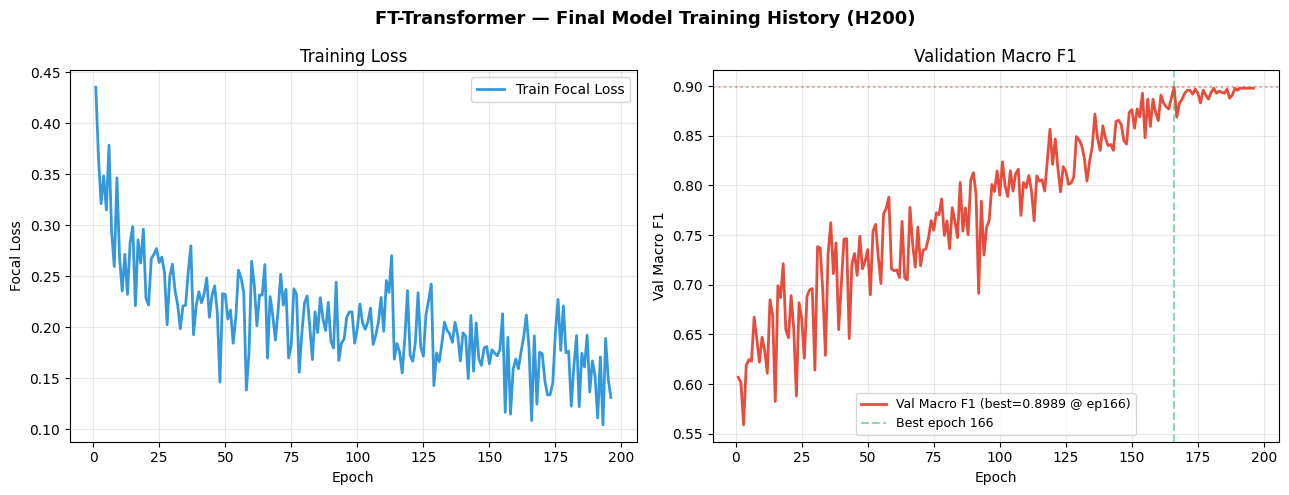

✅ Saved → /teamspace/studios/this_studio/outputs/training_history_ft.png
   Total epochs trained : 196
   Best Val Macro F1    : 0.8989 @ epoch 166


In [29]:
# ─── CELL 24 — Training History Plot ─────────────────────────────────────────

if history_best and len(history_best['loss']) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('FT-Transformer — Final Model Training History (H200)',
                 fontsize=13, fontweight='bold')

    ep = range(1, len(history_best['loss']) + 1)

    # Loss
    ax1.plot(ep, history_best['loss'], '#3498db', lw=2, label='Train Focal Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Focal Loss')
    ax1.set_title('Training Loss'); ax1.grid(alpha=0.3)
    ax1.legend()

    # Val F1
    best_ep  = int(np.argmax(history_best['val_f1'])) + 1
    best_val = max(history_best['val_f1'])
    ax2.plot(ep, history_best['val_f1'], '#e74c3c', lw=2,
             label=f'Val Macro F1 (best={best_val:.4f} @ ep{best_ep})')
    ax2.axhline(y=best_val, color='#e74c3c', ls=':', alpha=0.5)
    ax2.axvline(x=best_ep,  color='#27ae60', ls='--', alpha=0.5,
                label=f'Best epoch {best_ep}')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Macro F1')
    ax2.set_title('Validation Macro F1')
    ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

    plt.tight_layout()
    save_path = f'{OUT}/training_history_ft.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {save_path}")
    print(f"   Total epochs trained : {len(ep)}")
    print(f"   Best Val Macro F1    : {best_val:.4f} @ epoch {best_ep}")
else:
    print("⚠️  history_best is empty — check Cell 23 ran successfully")


In [30]:
# ─── CELL 25 — Weighted Soft-Voting Ensemble ─────────────────────────────────
# Weights based on CV Macro F1 performance:
#   LightGBM     : 0.8490 → 0.35
#   XGBoost      : ~0.84  → 0.30
#   FT-Transformer: 0.8017 → 0.25  (adds diversity despite lower CV score)
#   DNN          : 0.8067 → 0.10  (weakest — smallest weight)
# Sum = 1.0

print("="*60)
print("  Weighted Soft-Voting Ensemble")
print("  LightGBM + XGBoost + FT-Transformer + DNN")
print("="*60)

# ── Ensemble weights ──────────────────────────────────────────────────────────
ENS_W = {
    'xgb': 0.30,
    'lgb': 0.35,
    'ft' : 0.25,
    'dnn': 0.10,
}
print(f"\n  Weights: {ENS_W}")
assert abs(sum(ENS_W.values()) - 1.0) < 1e-6, "Weights must sum to 1.0"

# ── Weighted average of test probabilities ────────────────────────────────────
y_proba_ens = (
    ENS_W['xgb'] * y_proba_xgb      +
    ENS_W['lgb'] * y_proba_lgb      +
    ENS_W['ft']  * y_proba_ft_test  +
    ENS_W['dnn'] * y_proba_dnn
)
y_pred_ens  = y_proba_ens.argmax(1)
results_ens = evaluate_model(
    y_test, y_pred_ens, y_proba_ens, 'Ensemble (XGB+LGB+FT+DNN)'
)

# ── OOF ensemble for threshold tuning ────────────────────────────────────────
# Use OOF probas (not test) to find optimal per-class bias → no leakage
y_proba_ens_oof = (
    ENS_W['xgb'] * oof_proba_xgb  +
    ENS_W['lgb'] * oof_proba_lgb  +
    ENS_W['ft']  * oof_proba_ft   +
    ENS_W['dnn'] * oof_proba_dnn
)

print("\n  Threshold tuning on OOF predictions...")
best_bias = tune_thresholds(
    y_trainval, y_proba_ens_oof, N_CLASSES, CLASS_NAMES
)

# ── Apply tuned thresholds to test set ───────────────────────────────────────
y_proba_ens_tuned = y_proba_ens + best_bias
y_pred_ens_tuned  = y_proba_ens_tuned.argmax(1)
results_ens_tuned = evaluate_model(
    y_test, y_pred_ens_tuned, y_proba_ens_tuned,
    'Ensemble + Threshold Tuning'
)
torch.cuda.empty_cache()


  Weighted Soft-Voting Ensemble
  LightGBM + XGBoost + FT-Transformer + DNN

  Weights: {'xgb': 0.3, 'lgb': 0.35, 'ft': 0.25, 'dnn': 0.1}

  Full Report: Ensemble (XGB+LGB+FT+DNN)
              precision    recall  f1-score   support

      Normal       0.98      0.95      0.96      2136
 Obstruction       0.74      0.89      0.81       236
 Restriction       0.69      0.84      0.76       118

    accuracy                           0.94      2490
   macro avg       0.80      0.89      0.84      2490
weighted avg       0.94      0.94      0.94      2490

  Accuracy   : 0.9361
  Macro F1   : 0.8431
  Weighted F1: 0.9386
  Macro AUC  : 0.9828

  Threshold tuning on OOF predictions...
  Threshold tuning : 0.8442 → 0.8533 (+0.0091)
  Bias             : {'Normal': 0.0113, 'Obstruction': -0.435, 'Restriction': -0.2589}

  Full Report: Ensemble + Threshold Tuning
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97      2136
 Obstruction       0.8


  Stratified 5-Fold CV Summary  +  Test Set Performance

  Model                   CV F1      ±   Test F1   Test Acc   Test AUC
  -----------------------------------------------------------------
  XGBoost                0.8463 0.0061    0.8513     0.9414     0.9864
  LightGBM               0.8490 0.0058    0.8387     0.9382     0.9854
  VanillaDNN             0.8067 0.0058    0.8202     0.9205     0.9709
  FT-Transformer         0.8017 0.0067    0.8153     0.9193     0.9751
  Ensemble                    —      —    0.8431     0.9361     0.9828
  Ensemble+Thresh             —      —    0.8543     0.9454     0.9828
  -----------------------------------------------------------------


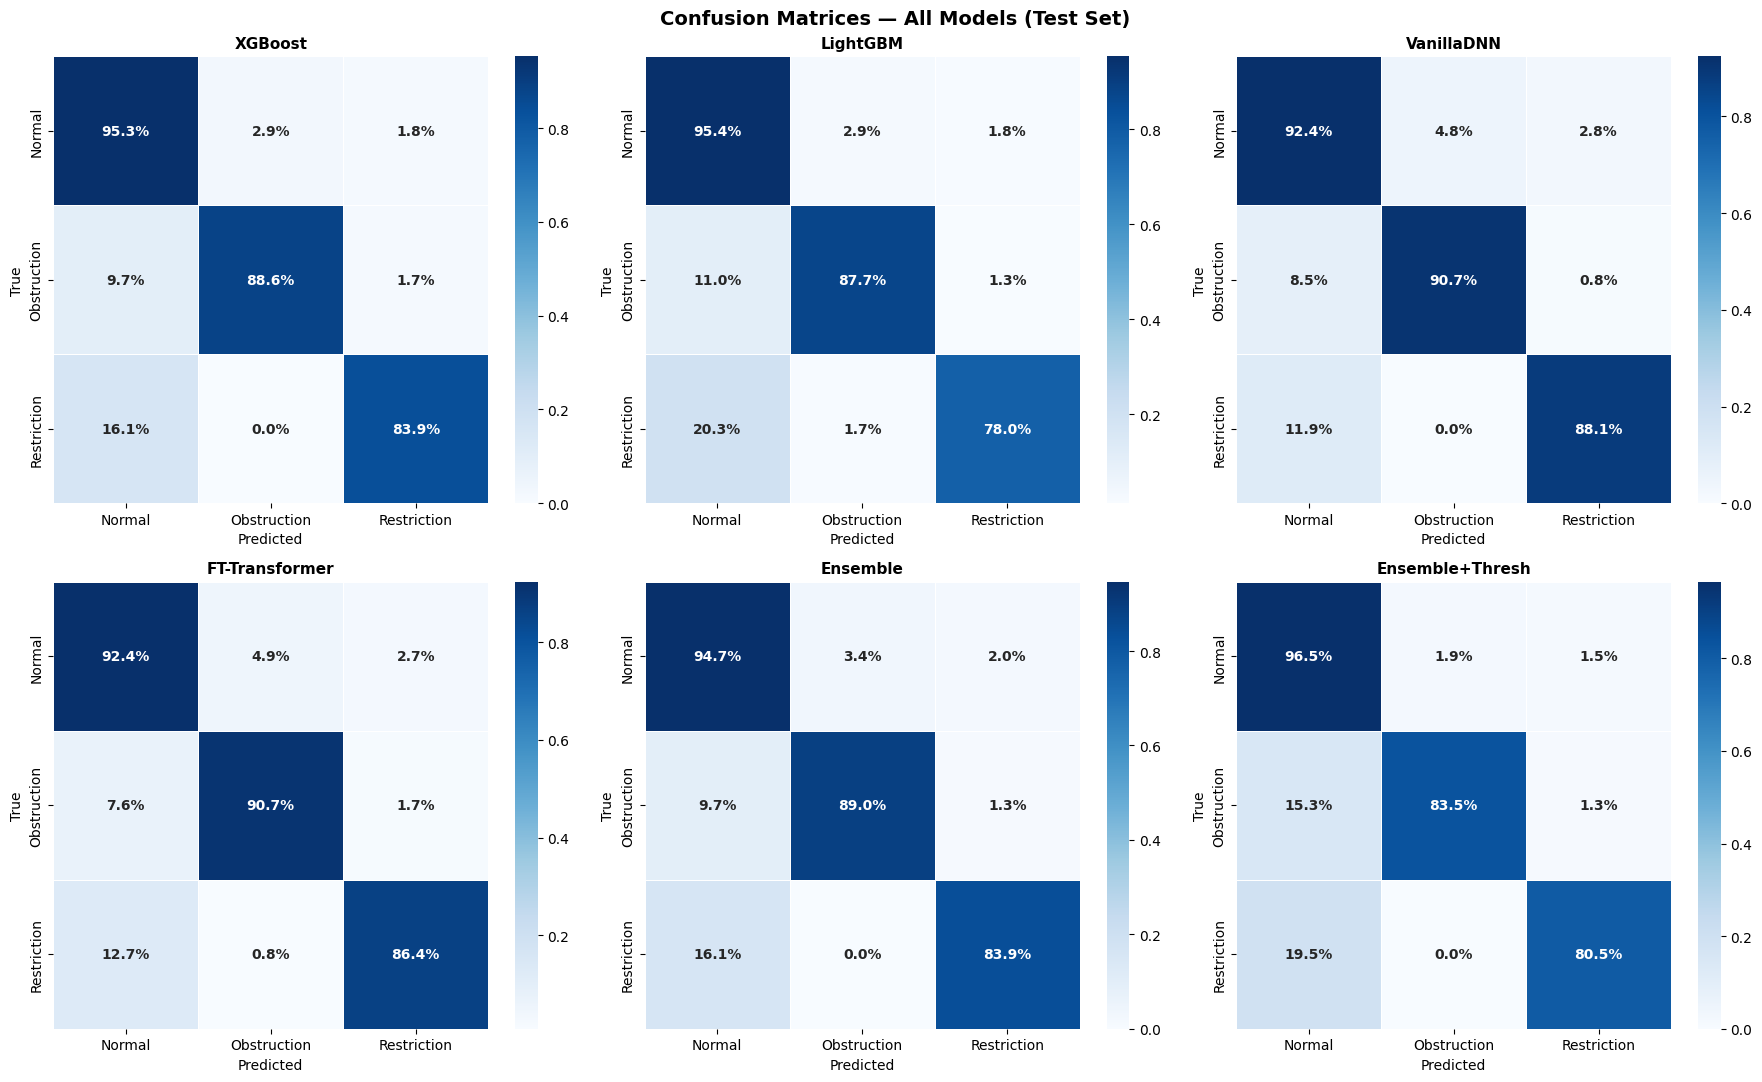


✅ Saved → /teamspace/studios/this_studio/outputs/confusion_matrices_all.png
✅ Saved → /teamspace/studios/this_studio/outputs/model_summary.csv


In [31]:
# ─── CELL 26 — CV Summary + Confusion Matrix Grid ────────────────────────────

from sklearn.preprocessing import label_binarize

# ── CV Summary table ─────────────────────────────────────────────────────────
print("\n" + "="*70)
print("  Stratified 5-Fold CV Summary  +  Test Set Performance")
print("="*70)

cv_models = {
    'XGBoost'       : (oof_proba_xgb, cv_f1_xgb,  y_proba_xgb,  y_pred_xgb),
    'LightGBM'      : (oof_proba_lgb, cv_f1_lgb,  y_proba_lgb,  y_pred_lgb),
    'VanillaDNN'    : (oof_proba_dnn, cv_f1_dnn,  y_proba_dnn,  y_pred_dnn),
    'FT-Transformer': (oof_proba_ft,  cv_f1_ft,   y_proba_ft_test, y_pred_ft),
}

summary_rows = []
print(f"\n  {'Model':<20} {'CV F1':>8} {'±':>6} {'Test F1':>9} "
      f"{'Test Acc':>10} {'Test AUC':>10}")
print("  " + "-"*65)

for name, (oof_p, fold_f1s, test_p, test_pred) in cv_models.items():
    oof_pred = oof_p.argmax(1)
    cv_mean  = np.mean(fold_f1s)
    cv_std   = np.std(fold_f1s)
    t_f1     = f1_score(y_test, test_pred, average='macro')
    t_acc    = accuracy_score(y_test, test_pred)
    yb       = label_binarize(y_test, classes=list(range(N_CLASSES)))
    t_auc    = roc_auc_score(yb, test_p, average='macro', multi_class='ovr')

    summary_rows.append({
        'Model': name, 'CV F1': cv_mean, 'CV Std': cv_std,
        'Test F1': t_f1, 'Test Acc': t_acc, 'Test AUC': t_auc
    })
    print(f"  {name:<20} {cv_mean:>8.4f} {cv_std:>6.4f} "
          f"{t_f1:>9.4f} {t_acc:>10.4f} {t_auc:>10.4f}")

# Ensemble rows
for ens_name, ens_pred, ens_proba in [
    ('Ensemble',        y_pred_ens,       y_proba_ens),
    ('Ensemble+Thresh', y_pred_ens_tuned, y_proba_ens_tuned),
]:
    t_f1  = f1_score(y_test, ens_pred, average='macro')
    t_acc = accuracy_score(y_test, ens_pred)
    yb    = label_binarize(y_test, classes=list(range(N_CLASSES)))
    t_auc = roc_auc_score(yb, ens_proba, average='macro', multi_class='ovr')
    summary_rows.append({
        'Model': ens_name, 'CV F1': None, 'CV Std': None,
        'Test F1': t_f1, 'Test Acc': t_acc, 'Test AUC': t_auc
    })
    print(f"  {ens_name:<20} {'—':>8} {'—':>6} "
          f"{t_f1:>9.4f} {t_acc:>10.4f} {t_auc:>10.4f}")

print("  " + "-"*65)

# ── Confusion Matrix Grid ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Confusion Matrices — All Models (Test Set)',
             fontsize=14, fontweight='bold')

plot_pairs = [
    ('XGBoost',          y_pred_xgb),
    ('LightGBM',         y_pred_lgb),
    ('VanillaDNN',       y_pred_dnn),
    ('FT-Transformer',   y_pred_ft),
    ('Ensemble',         y_pred_ens),
    ('Ensemble+Thresh',  y_pred_ens_tuned),
]
for ax, (name, pred) in zip(axes.flat, plot_pairs):
    plot_cm(y_test, pred, name, ax=ax)

plt.tight_layout()
save_path = f'{OUT}/confusion_matrices_all.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved → {save_path}")

# ── Save summary CSV ──────────────────────────────────────────────────────────
import pandas as pd
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(f'{OUT}/model_summary.csv', index=False)
print(f"✅ Saved → {OUT}/model_summary.csv")


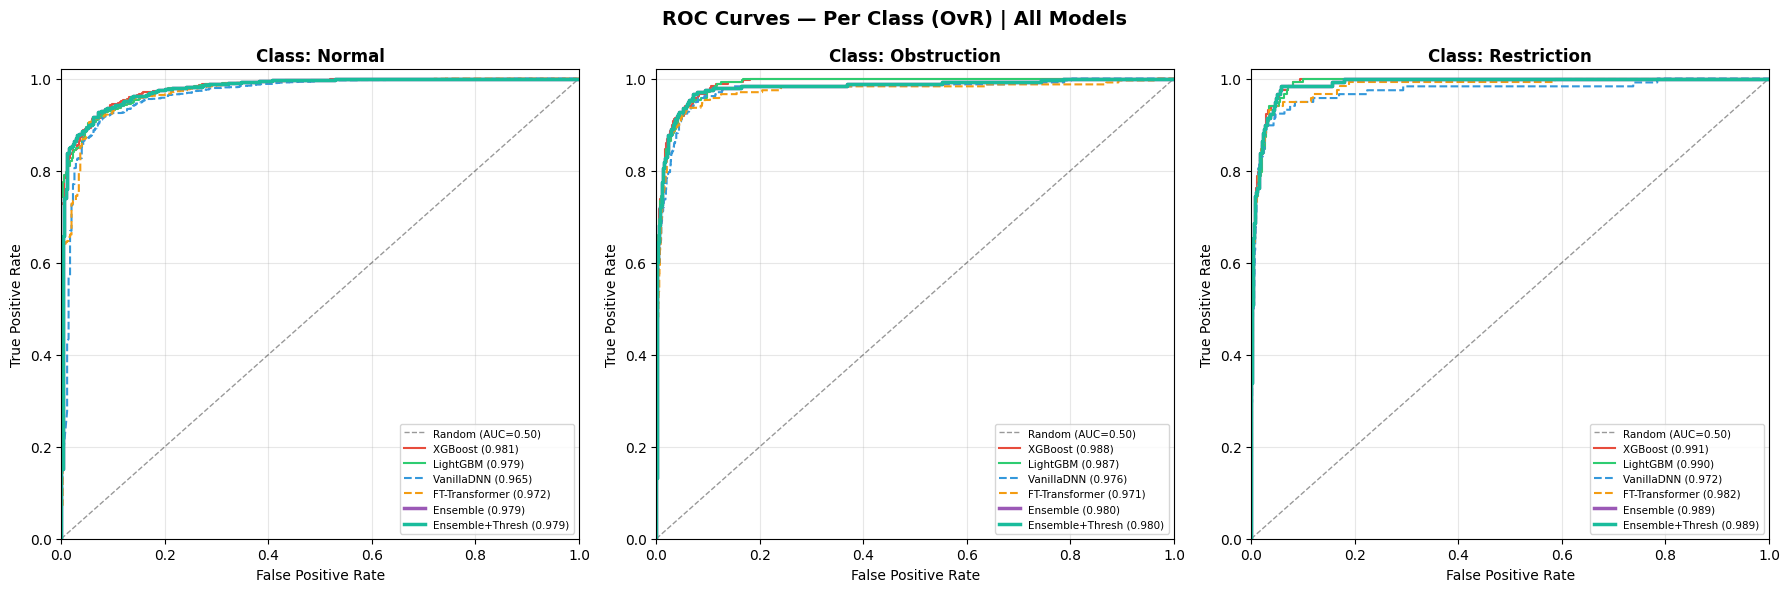

✅ Saved → /teamspace/studios/this_studio/outputs/roc_curves_all_models.png

  Model                           Normal     Obstruction     Restriction
  ------------------------------------------------------------
  XGBoost                         0.9805          0.9882          0.9906
  LightGBM                        0.9792          0.9874          0.9896
  VanillaDNN                      0.9650          0.9757          0.9719
  FT-Transformer                  0.9724          0.9713          0.9816
  Ensemble                        0.9790          0.9801          0.9894
  Ensemble+Thresh                 0.9790          0.9801          0.9894


In [32]:
# ─── CELL 27 — ROC Curves (All Models + Ensemble) ────────────────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=list(range(N_CLASSES)))

models_roc = {
    'XGBoost'          : y_proba_xgb,
    'LightGBM'         : y_proba_lgb,
    'VanillaDNN'       : y_proba_dnn,
    'FT-Transformer'   : y_proba_ft_test,
    'Ensemble'         : y_proba_ens,
    'Ensemble+Thresh'  : y_proba_ens_tuned,
}

LINE_STYLES = ['-', '-', '--', '--', '-', '-']
LINE_COLORS = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ROC Curves — Per Class (OvR) | All Models',
             fontsize=14, fontweight='bold')

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    ax = axes[cls_idx]
    ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.4, label='Random (AUC=0.50)')

    for (name, proba), ls, col in zip(
        models_roc.items(), LINE_STYLES, LINE_COLORS
    ):
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], proba[:, cls_idx])
        roc_auc     = auc(fpr, tpr)
        lw          = 2.5 if 'Ensemble' in name else 1.5
        ax.plot(fpr, tpr, color=col, lw=lw, ls=ls,
                label=f'{name} ({roc_auc:.3f})')

    ax.set_title(f'Class: {cls_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7.5, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.tight_layout()
save_path = f'{OUT}/roc_curves_all_models.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {save_path}")

# ── Per-class AUC summary table ───────────────────────────────────────────────
print(f"\n  {'Model':<22}", end="")
for c in CLASS_NAMES:
    print(f"  {c:>14}", end="")
print()
print("  " + "-"*60)

for name, proba in models_roc.items():
    print(f"  {name:<22}", end="")
    for cls_idx in range(N_CLASSES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], proba[:, cls_idx])
        print(f"  {auc(fpr, tpr):>14.4f}", end="")
    print()


Computing SHAP values — XGBoost...
  ✅ XGBoost SHAP computed | shape: (2490, 34)
Computing SHAP values — LightGBM...
  ✅ LightGBM SHAP computed | shape: (2490, 34)


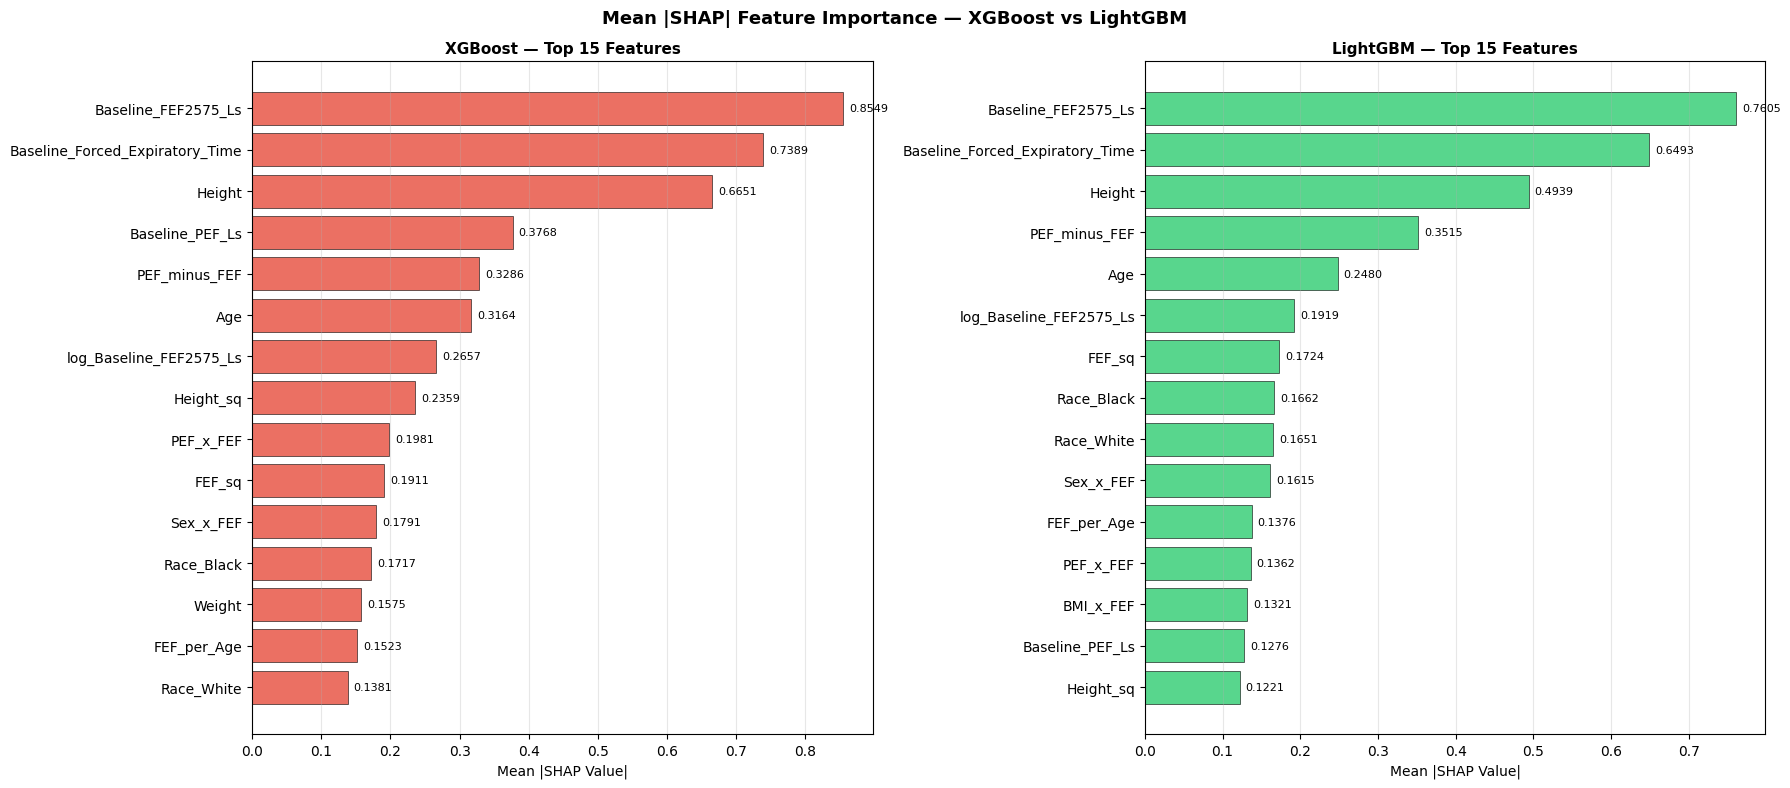

✅ Saved → /teamspace/studios/this_studio/outputs/shap_feature_importance.png


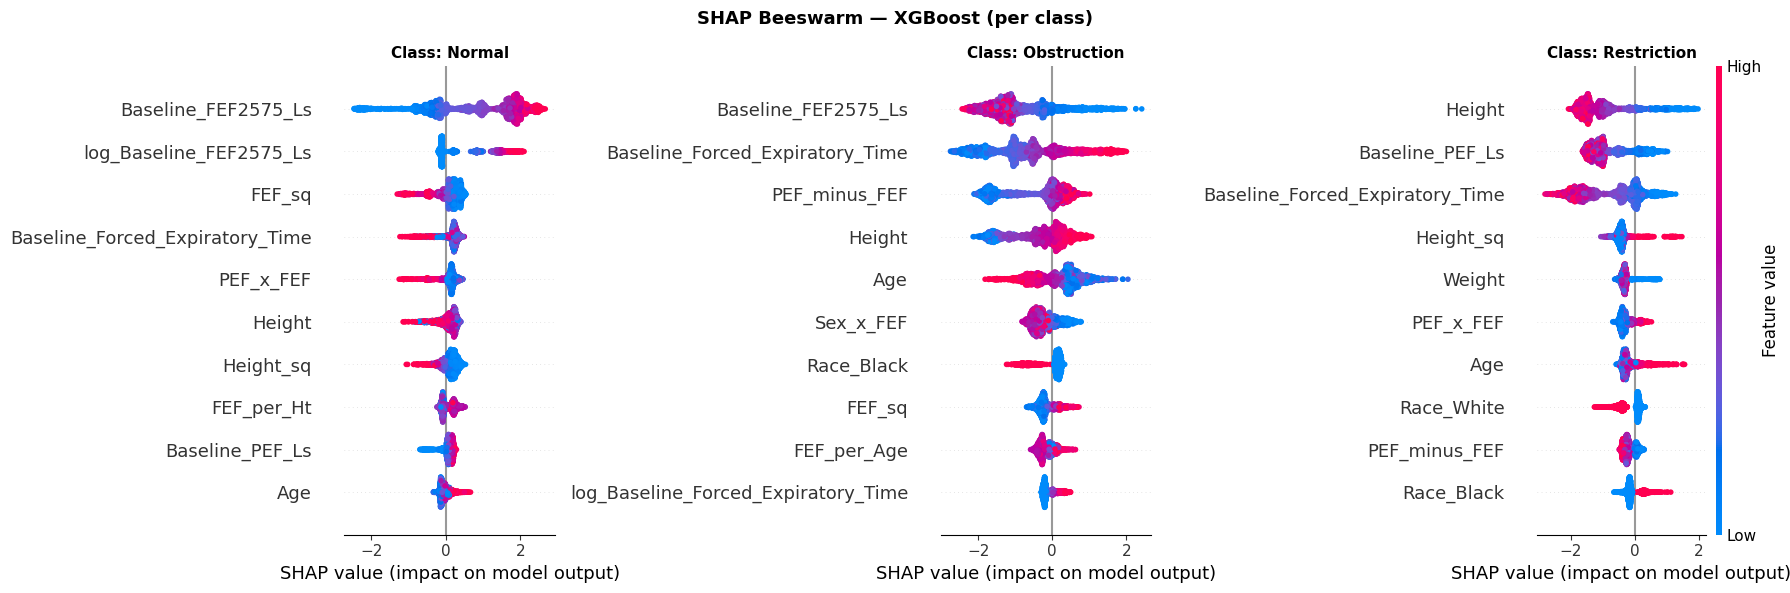

✅ Saved → /teamspace/studios/this_studio/outputs/shap_beeswarm_xgb.png


In [33]:
# ─── CELL 28 — SHAP Explainability: XGBoost + LightGBM ──────────────────────
# Tree SHAP is exact and fast — no sampling needed.
# FT-Transformer SHAP (DeepExplainer) is in Cell 29.

import shap
import matplotlib.pyplot as plt
import numpy as np

shap.initjs()

# Use test set as background (2490 samples — manageable for tree SHAP)
X_shap = X_test_np.copy()

# ── XGBoost SHAP ──────────────────────────────────────────────────────────────
print("Computing SHAP values — XGBoost...")
explainer_xgb  = shap.TreeExplainer(xgb_final)
shap_vals_xgb  = explainer_xgb.shap_values(X_shap)   # list of arrays [n_classes]

# If shap returns 3D array (n_samples, n_features, n_classes), handle both
if isinstance(shap_vals_xgb, list):
    shap_xgb_mean = np.mean([np.abs(sv) for sv in shap_vals_xgb], axis=0)
else:
    shap_xgb_mean = np.abs(shap_vals_xgb).mean(axis=-1)

print(f"  ✅ XGBoost SHAP computed | shape: {shap_xgb_mean.shape}")

# ── LightGBM SHAP ─────────────────────────────────────────────────────────────
print("Computing SHAP values — LightGBM...")
explainer_lgb  = shap.TreeExplainer(lgb_final)
shap_vals_lgb  = explainer_lgb.shap_values(X_shap)

if isinstance(shap_vals_lgb, list):
    shap_lgb_mean = np.mean([np.abs(sv) for sv in shap_vals_lgb], axis=0)
else:
    shap_lgb_mean = np.abs(shap_vals_lgb).mean(axis=-1)

print(f"  ✅ LightGBM SHAP computed | shape: {shap_lgb_mean.shape}")

# ── Plot: Mean |SHAP| per feature for both models ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Mean |SHAP| Feature Importance — XGBoost vs LightGBM',
             fontsize=13, fontweight='bold')

for ax, shap_mean, model_name, color in zip(
    axes,
    [shap_xgb_mean, shap_lgb_mean],
    ['XGBoost', 'LightGBM'],
    ['#e74c3c', '#2ecc71']
):
    feat_imp  = shap_mean.mean(axis=0)   # mean across samples
    sorted_idx= np.argsort(feat_imp)[::-1]
    top_n     = min(15, len(feature_names))
    top_idx   = sorted_idx[:top_n][::-1] # reverse for horizontal bar

    bars = ax.barh(
        [feature_names[i] for i in top_idx],
        feat_imp[top_idx],
        color=color, alpha=0.8, edgecolor='black', linewidth=0.5
    )
    for bar, val in zip(bars, feat_imp[top_idx]):
        ax.text(val + feat_imp.max()*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

    ax.set_title(f'{model_name} — Top {top_n} Features',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Mean |SHAP Value|')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
save_path = f'{OUT}/shap_feature_importance.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {save_path}")

# ── Per-class SHAP beeswarm: XGBoost ─────────────────────────────────────────
fig, axes = plt.subplots(1, N_CLASSES, figsize=(18, 6))
fig.suptitle('SHAP Beeswarm — XGBoost (per class)',
             fontsize=13, fontweight='bold')

shap_list = shap_vals_xgb if isinstance(shap_vals_xgb, list) \
            else [shap_vals_xgb[:,:,i] for i in range(N_CLASSES)]

for cls_idx, (ax, cls_name) in enumerate(zip(axes, CLASS_NAMES)):
    plt.sca(ax)
    shap.summary_plot(
        shap_list[cls_idx], X_shap,
        feature_names = feature_names,
        max_display   = 10,
        show          = False,
        plot_size     = None,
        color_bar     = (cls_idx == N_CLASSES - 1),  # only last plot gets colorbar
    )
    ax.set_title(f'Class: {cls_name}', fontweight='bold', fontsize=11)

plt.tight_layout()
save_path = f'{OUT}/shap_beeswarm_xgb.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {save_path}")


  sv type  : <class 'numpy.ndarray'>
  sv shape : (128, 34, 3)

  ✅ SHAP shape per class : (2490, 34)
     Expected            : (2490, 34)


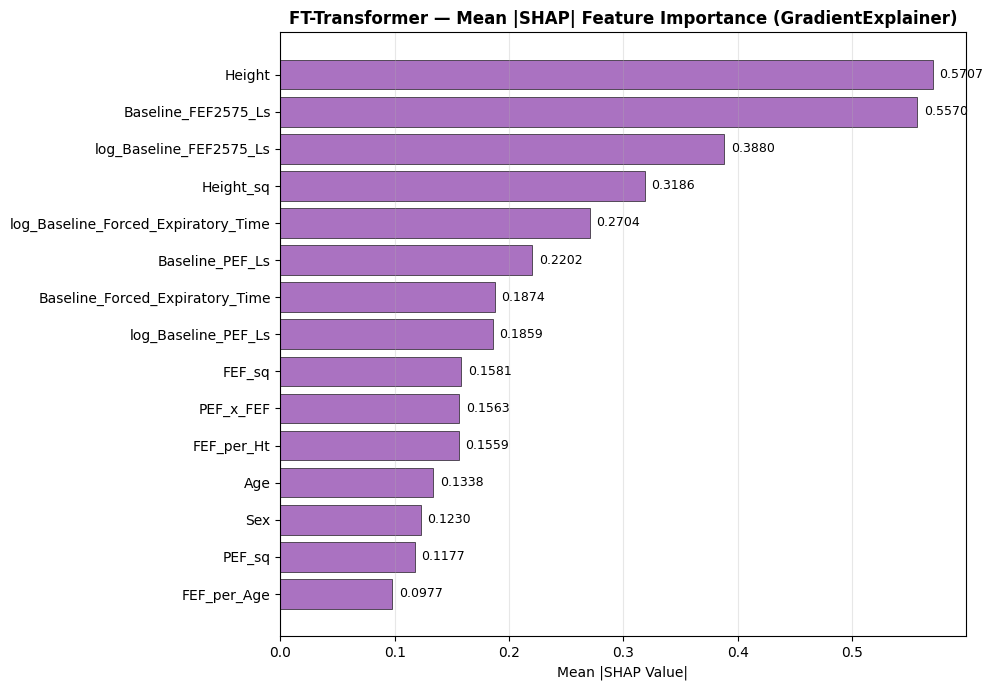

✅ Saved → /teamspace/studios/this_studio/outputs/shap_ft_transformer.png


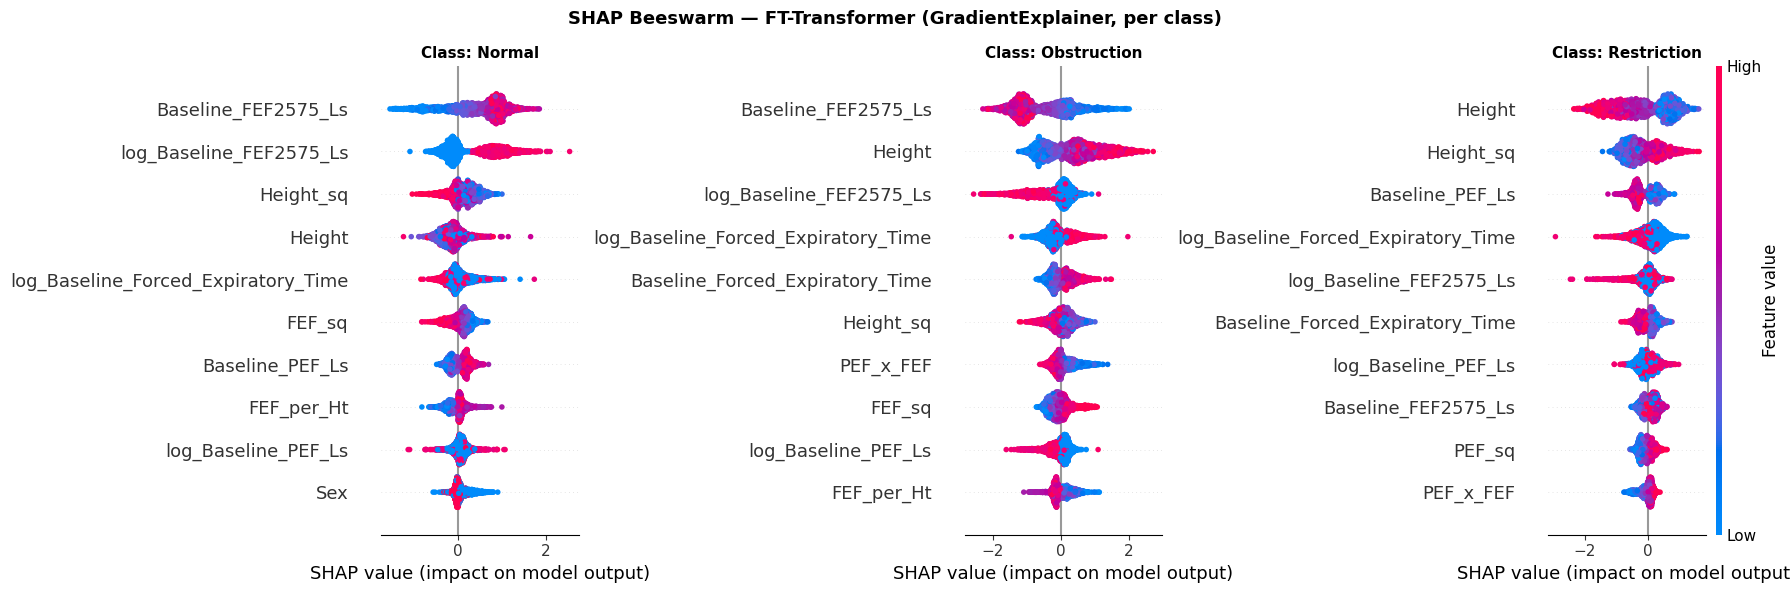

✅ Saved → /teamspace/studios/this_studio/outputs/shap_beeswarm_ft.png


In [37]:
# ─── CELL 29 — Fix: correct SHAP array handling ──────────────────────────────

# ── Inspect what GradientExplainer actually returned ─────────────────────────
sample_sv = shap_vals_ft[0]
print(f"  sv type  : {type(sample_sv)}")
if isinstance(sample_sv, list):
    print(f"  sv is list of {len(sample_sv)} arrays, each shape: {sample_sv[0].shape}")
else:
    print(f"  sv shape : {sample_sv.shape}")

# ── Concatenate per class — handles both list and 3D array ───────────────────
shap_per_class = [[] for _ in range(N_CLASSES)]

for sv in shap_vals_ft:
    if isinstance(sv, list):
        # list of N_CLASSES arrays each (batch, n_features) ← expected
        for c in range(N_CLASSES):
            shap_per_class[c].append(sv[c])
    elif isinstance(sv, np.ndarray) and sv.ndim == 3:
        if sv.shape[-1] == N_CLASSES:
            # shape: (batch, n_features, n_classes) ← GradientExplainer 3D
            for c in range(N_CLASSES):
                shap_per_class[c].append(sv[:, :, c])
        elif sv.shape[0] == N_CLASSES:
            # shape: (n_classes, batch, n_features)
            for c in range(N_CLASSES):
                shap_per_class[c].append(sv[c])
    else:
        # Fallback: 2D array (batch, n_features) — single output
        for c in range(N_CLASSES):
            shap_per_class[c].append(sv)

shap_ft_per_class = [
    np.concatenate(shap_per_class[c], axis=0) for c in range(N_CLASSES)
]
print(f"\n  ✅ SHAP shape per class : {shap_ft_per_class[0].shape}")
print(f"     Expected            : ({len(X_test_qt)}, {N_FEATURES})")

# ── Mean |SHAP| bar chart ─────────────────────────────────────────────────────
shap_ft_mean = np.mean([np.abs(sv) for sv in shap_ft_per_class], axis=0)
feat_imp_ft  = shap_ft_mean.mean(axis=0)
sorted_idx   = np.argsort(feat_imp_ft)[::-1]
top_n        = min(15, len(feature_names))
top_idx      = sorted_idx[:top_n][::-1]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    [feature_names[i] for i in top_idx],
    feat_imp_ft[top_idx],
    color='#9b59b6', alpha=0.85, edgecolor='black', linewidth=0.5
)
for bar, val in zip(bars, feat_imp_ft[top_idx]):
    ax.text(val + feat_imp_ft.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title(
    'FT-Transformer — Mean |SHAP| Feature Importance (GradientExplainer)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Mean |SHAP Value|')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_path = f'{OUT}/shap_ft_transformer.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {save_path}")

# ── Per-class beeswarm ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, N_CLASSES, figsize=(18, 6))
fig.suptitle('SHAP Beeswarm — FT-Transformer (GradientExplainer, per class)',
             fontsize=13, fontweight='bold')

for cls_idx, (ax, cls_name) in enumerate(zip(axes, CLASS_NAMES)):
    plt.sca(ax)
    shap.summary_plot(
        shap_ft_per_class[cls_idx],        # (2490, 34) ← now correct
        X_test_qt,                          # (2490, 34) ← matches
        feature_names = feature_names,
        max_display   = 10,
        show          = False,
        plot_size     = None,
        color_bar     = (cls_idx == N_CLASSES - 1),
    )
    ax.set_title(f'Class: {cls_name}', fontweight='bold', fontsize=11)

plt.tight_layout()
save_path = f'{OUT}/shap_beeswarm_ft.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {save_path}")
torch.cuda.empty_cache()


Sample patients selected for attention viz:
  Normal         : test[311]  confidence=0.8719
  Obstruction    : test[1507]  confidence=0.9148
  Restriction    : test[288]  confidence=0.9249

✅ Attention weights extracted from last 2 blocks


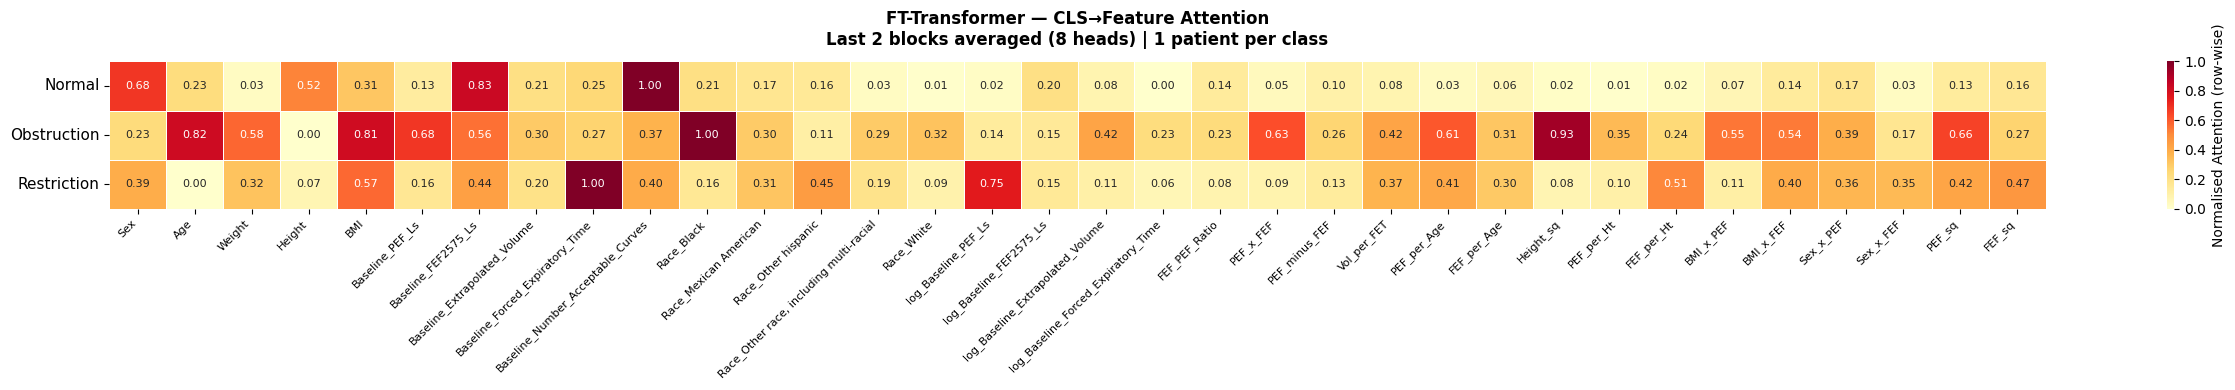

✅ Saved → /teamspace/studios/this_studio/outputs/attention_heatmap_ft.png

  Top 5 attended features per class:
  Normal         : ['Baseline_Number_Acceptable_Curves', 'Baseline_FEF2575_Ls', 'Sex', 'Height', 'BMI']
  Obstruction    : ['Race_Black', 'Height_sq', 'Age', 'BMI', 'Baseline_PEF_Ls']
  Restriction    : ['Baseline_Forced_Expiratory_Time', 'log_Baseline_PEF_Ls', 'BMI', 'FEF_per_Ht', 'FEF_sq']


In [38]:
# ─── CELL 30 — Attention Heatmap: FT-Transformer ─────────────────────────────
# Manually extracts CLS→feature attention from last 2 blocks.
# Uses raw model (not compiled) in FP32 mode for clean gradient flow.

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ft_model_raw = getattr(ft_model_best, '_orig_mod', ft_model_best)
ft_model_raw.eval()

# ── Pick 1 high-confidence patient per class from test set ───────────────────
sample_indices = {}
for cls in range(N_CLASSES):
    cls_idx  = np.where(y_test == cls)[0]
    conf     = y_proba_ft_test[cls_idx, cls]
    best     = cls_idx[np.argmax(conf)]
    sample_indices[CLASS_NAMES[cls]] = best

print("Sample patients selected for attention viz:")
for cls_name, idx in sample_indices.items():
    conf = y_proba_ft_test[idx, CLASS_NAMES.index(cls_name)]
    print(f"  {cls_name:<15}: test[{idx}]  confidence={conf:.4f}")

# ── Extract attention weights per sample ─────────────────────────────────────
all_cls_attentions = {}

with torch.no_grad():
    for cls_name, idx in sample_indices.items():
        x_in   = torch.FloatTensor(X_test_qt[[idx]]).to(device)
        B      = 1

        # Build token sequence manually
        tokens = torch.cat(
            [ft_model_raw.cls_token.expand(B, -1, -1),
             ft_model_raw.tokenizer(x_in.float())],
            dim=1
        )   # (1, N_FEATURES+1, D_TOKEN)

        block_attns = []

        for block in ft_model_raw.blocks:
            x_norm = block.norm1(tokens).float()
            T      = tokens.shape[1]
            H, Dh  = N_HEADS, D_TOKEN // N_HEADS

            # Manual QKV — bypass FlashAttn to get actual attention weights
            QKV    = block.attn.qkv(x_norm)
            QKV    = QKV.reshape(B, T, 3, H, Dh).permute(2, 0, 3, 1, 4)
            Q, K   = QKV[0].float(), QKV[1].float()
            scale  = Dh ** -0.5
            scores = (Q @ K.transpose(-2, -1)) * scale   # (1, H, T, T)
            attn_w = torch.softmax(scores, dim=-1)        # (1, H, T, T)
            block_attns.append(
                attn_w.squeeze(0).cpu().float().numpy()   # (H, T, T)
            )

            # Continue forward normally
            a, _   = block.attn(block.norm1(tokens))
            tokens = tokens + a
            tokens = tokens + block.ffn(block.norm2(tokens))

        # Average last 2 blocks, all heads → CLS row, feature cols only
        last2        = np.mean(block_attns[-2:], axis=0)   # (H, T, T)
        cls_to_feat  = last2[:, 0, 1:].mean(axis=0)        # (N_FEATURES,)
        all_cls_attentions[cls_name] = cls_to_feat

print("\n✅ Attention weights extracted from last 2 blocks")

# ── Build attention matrix ────────────────────────────────────────────────────
attn_matrix = np.array([all_cls_attentions[c] for c in CLASS_NAMES])

# Row-wise min-max normalise for clean cross-class comparison
row_min  = attn_matrix.min(1, keepdims=True)
row_max  = attn_matrix.max(1, keepdims=True)
attn_norm= (attn_matrix - row_min) / (row_max - row_min + 1e-9)

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig_w = max(16, N_FEATURES * 0.75)
fig, ax = plt.subplots(figsize=(fig_w, 4))

sns.heatmap(
    attn_norm,
    xticklabels = feature_names,
    yticklabels = CLASS_NAMES,
    cmap        = 'YlOrRd',
    annot       = True, fmt='.2f',
    linewidths  = 0.5, ax=ax,
    annot_kws   = {'size': 8},
    cbar_kws    = {'label': 'Normalised Attention (row-wise)'}
)
ax.set_title(
    'FT-Transformer — CLS→Feature Attention\n'
    f'Last 2 blocks averaged ({N_HEADS} heads) | 1 patient per class',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
save_path = f'{OUT}/attention_heatmap_ft.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {save_path}")

# ── Top attended features per class ──────────────────────────────────────────
print("\n  Top 5 attended features per class:")
for cls_name in CLASS_NAMES:
    att  = all_cls_attentions[cls_name]
    top5 = np.argsort(att)[::-1][:5]
    print(f"  {cls_name:<15}: "
          f"{[feature_names[i] for i in top5]}")

torch.cuda.empty_cache()


In [41]:
# ─── CELL 31 — Save All Models + Artifacts (clean torch.compile state) ────────
import pickle, json, os
import torch, numpy as np

MODELS_DIR = f'{OUT}/saved_models'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_path = f'{MODELS_DIR}/xgb_final.json'
xgb_final.save_model(xgb_path)
print(f"✅ XGBoost          → {xgb_path}")

# ── LightGBM ──────────────────────────────────────────────────────────────────
lgb_path = f'{MODELS_DIR}/lgb_final.txt'
lgb_final.booster_.save_model(lgb_path)
print(f"✅ LightGBM         → {lgb_path}")

# ── VanillaDNN ────────────────────────────────────────────────────────────────
torch.save({
    'model_state_dict': dnn_final.state_dict(),
    'n_features'      : N_FEATURES,
    'n_classes'       : N_CLASSES,
    'architecture'    : f'{N_FEATURES}→1024→512→256→128→{N_CLASSES}',
    'dropout'         : 0.20,
}, f'{MODELS_DIR}/dnn_final.pt')
print(f"✅ VanillaDNN       → {MODELS_DIR}/dnn_final.pt")

# ── FT-Transformer — strip torch.compile .x/.y buffer artifacts ──────────────
ft_model_raw = getattr(ft_model_best, '_orig_mod', ft_model_best)

ft_state_clean = {
    k: v for k, v in ft_model_raw.state_dict().items()
    if not (k.endswith('.x') or k.endswith('.y'))
}
print(f"   FT state keys    : total={len(ft_model_raw.state_dict())} "
      f"| clean={len(ft_state_clean)} "
      f"| stripped={len(ft_model_raw.state_dict()) - len(ft_state_clean)}")

torch.save({
    'model_state_dict': ft_state_clean,
    'n_features'      : N_FEATURES,
    'n_classes'       : N_CLASSES,
    'd_token'         : D_TOKEN,
    'n_layers'        : N_LAYERS,
    'n_heads'         : N_HEADS,
    'ffn_factor'      : FFN_FACTOR,
    'attn_dropout'    : ATTN_DROPOUT,
    'ffn_dropout'     : FFN_DROPOUT,
}, f'{MODELS_DIR}/ft_transformer_final.pt')
print(f"✅ FT-Transformer   → {MODELS_DIR}/ft_transformer_final.pt")

# ── QuantileTransformer ───────────────────────────────────────────────────────
with open(f'{MODELS_DIR}/qt_full.pkl', 'wb') as f:
    pickle.dump(qt_full, f)
print(f"✅ QuantileTransformer → {MODELS_DIR}/qt_full.pkl")

# ── Feature names ─────────────────────────────────────────────────────────────
with open(f'{MODELS_DIR}/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)
print(f"✅ Feature names    → {MODELS_DIR}/feature_names.pkl")

# ── OOF probabilities + ensemble bias ────────────────────────────────────────
for name, arr in [
    ('oof_proba_xgb', oof_proba_xgb),
    ('oof_proba_lgb', oof_proba_lgb),
    ('oof_proba_dnn', oof_proba_dnn),
    ('oof_proba_ft',  oof_proba_ft),
    ('ensemble_bias', best_bias),
]:
    np.save(f'{MODELS_DIR}/{name}.npy', arr)
print(f"✅ OOF probas + bias → {MODELS_DIR}/")

# ── Experiment summary JSON ───────────────────────────────────────────────────
summary = {
    'gpu'             : torch.cuda.get_device_name(0),
    'cuda_version'    : torch.version.cuda,
    'compute_dtype'   : str(COMPUTE_DTYPE),
    'torch_version'   : torch.__version__,
    'n_features'      : N_FEATURES,
    'n_classes'       : N_CLASSES,
    'class_names'     : CLASS_NAMES,
    'feature_names'   : feature_names,
    'ft_config'       : {
        'd_token'  : D_TOKEN,  'n_layers': N_LAYERS,
        'n_heads'  : N_HEADS,  'ffn_factor': FFN_FACTOR,
    },
    'ensemble_weights': ENS_W,
    'ensemble_bias'   : best_bias.tolist(),
    'cv_results'      : {
        'XGBoost'       : {'cv_f1': float(np.mean(cv_f1_xgb)),
                           'cv_std': float(np.std(cv_f1_xgb))},
        'LightGBM'      : {'cv_f1': float(np.mean(cv_f1_lgb)),
                           'cv_std': float(np.std(cv_f1_lgb))},
        'VanillaDNN'    : {'cv_f1': float(np.mean(cv_f1_dnn)),
                           'cv_std': float(np.std(cv_f1_dnn))},
        'FT-Transformer': {'cv_f1': float(np.mean(cv_f1_ft)),
                           'cv_std': float(np.std(cv_f1_ft))},
    },
    'test_results'    : {
        'XGBoost'         : results_xgb,
        'LightGBM'        : results_lgb,
        'VanillaDNN'      : results_dnn,
        'FT-Transformer'  : results_ft,
        'Ensemble'        : results_ens,
        'Ensemble+Thresh' : results_ens_tuned,
    }
}
with open(f'{OUT}/experiment_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✅ Summary JSON     → {OUT}/experiment_summary.json")

# ── Final leaderboard ─────────────────────────────────────────────────────────
print(f"\n{'='*58}")
print(f"  🏆 Final Leaderboard (Test Set)")
print(f"{'='*58}")
print(f"  {'Model':<22} {'Macro F1':>9} {'Accuracy':>10} {'AUC':>8}")
print(f"  {'-'*52}")
for name, r in [
    ('XGBoost',             results_xgb),
    ('LightGBM',            results_lgb),
    ('VanillaDNN',          results_dnn),
    ('FT-Transformer',      results_ft),
    ('Ensemble',            results_ens),
    ('Ensemble+Thresh 🥇',  results_ens_tuned),
]:
    print(f"  {name:<22} {r['Macro F1']:>9.4f} "
          f"{r['Accuracy']:>10.4f} {r['Macro AUC']:>8.4f}")
print(f"{'='*58}")
print(f"\n  All artifacts saved → {MODELS_DIR}/")


✅ XGBoost          → /teamspace/studios/this_studio/outputs/saved_models/xgb_final.json
✅ LightGBM         → /teamspace/studios/this_studio/outputs/saved_models/lgb_final.txt
✅ VanillaDNN       → /teamspace/studios/this_studio/outputs/saved_models/dnn_final.pt
   FT state keys    : total=87 | clean=73 | stripped=14
✅ FT-Transformer   → /teamspace/studios/this_studio/outputs/saved_models/ft_transformer_final.pt
✅ QuantileTransformer → /teamspace/studios/this_studio/outputs/saved_models/qt_full.pkl
✅ Feature names    → /teamspace/studios/this_studio/outputs/saved_models/feature_names.pkl
✅ OOF probas + bias → /teamspace/studios/this_studio/outputs/saved_models/
✅ Summary JSON     → /teamspace/studios/this_studio/outputs/experiment_summary.json

  🏆 Final Leaderboard (Test Set)
  Model                   Macro F1   Accuracy      AUC
  ----------------------------------------------------
  XGBoost                   0.8513     0.9414   0.9864
  LightGBM                  0.8387     0.9382   0

In [43]:
# ── Inference function ────────────────────────────────────────────────────────
def predict_new_patient(patient_data: dict,
                        return_proba: bool = False,
                        verbose: bool = True):
    """
    Predict lung disease class from raw spirometry features.

    Parameters
    ----------
    patient_data : dict  — raw feature key-value pairs
    return_proba : bool  — also return class probabilities
    verbose      : bool  — print detailed breakdown

    Returns
    -------
    pred_class : str
    proba_dict : dict  (only if return_proba=True)
    """
    # Step 1: DataFrame + feature engineering
    df             = pd.DataFrame([patient_data])
    df[TARGET_COL] = 0
    df_fe          = add_spirometry_features(df, TARGET_COL)
    X_raw          = df_fe.drop(columns=[TARGET_COL]).select_dtypes(include=[np.number])
    X_raw          = X_raw.reindex(columns=_feature_names, fill_value=0)
    X_raw          = X_raw.fillna(0).replace([np.inf, -np.inf], 0)

    X_np = X_raw.values.astype(np.float32)
    X_qt = _qt.transform(X_np).astype(np.float32)

    # Step 2: Individual probabilities
    p_xgb = _xgb.predict_proba(X_np)

    p_lgb = _lgb.predict(X_np)
    if p_lgb.ndim == 1:
        p_lgb = p_lgb.reshape(1, -1)

    with torch.no_grad():
        xt = torch.FloatTensor(X_qt).to(device)
        with torch.autocast(device_type='cuda', dtype=COMPUTE_DTYPE):
            p_dnn = torch.softmax(
                _dnn_inf(xt).float(), dim=-1
            ).cpu().numpy()
            p_ft  = torch.softmax(
                _ft_inf(xt).float(), dim=-1
            ).cpu().numpy()

    # Step 3: Weighted ensemble + threshold bias
    p_ens  = (
        _ENS_W['xgb'] * p_xgb +
        _ENS_W['lgb'] * p_lgb +
        _ENS_W['ft']  * p_ft  +
        _ENS_W['dnn'] * p_dnn
    )
    p_tuned    = p_ens + _bias                        # raw scores for argmax
    pred_idx   = int(p_tuned.argmax(axis=1)[0])
    pred_class = CLASS_NAMES[pred_idx]
    confidence = float(p_tuned[0, pred_idx])

    # ── Clipped version ONLY for display — does NOT affect prediction ─────────
    p_display  = np.clip(p_tuned, 0, None)            # no negatives shown
    p_display  = p_display / (p_display.sum(axis=1, keepdims=True) + 1e-9)  # renorm to 1.0

    # Step 4: Verbose output
    if verbose:
        print(f"\n{'='*52}")
        print(f"  🫁 Lung Disease Prediction")
        print(f"{'='*52}")
        print(f"  Prediction   : {pred_class}")
        print(f"  Confidence   : {p_display[0, pred_idx]:.1%}")
        print(f"\n  Probabilities (normalised display):")
        for i, cls in enumerate(CLASS_NAMES):
            bar   = '█' * int(p_display[0, i] * 30)
            arrow = ' ◄' if i == pred_idx else ''
            print(f"    {cls:<15}: {p_display[0, i]:.4f}  {bar}{arrow}")
        print(f"\n  Individual model votes:")
        for mname, p in [
            ('XGBoost',        p_xgb),
            ('LightGBM',       p_lgb),
            ('VanillaDNN',     p_dnn),
            ('FT-Transformer', p_ft),
        ]:
            vote  = CLASS_NAMES[int(p[0].argmax())]
            probs = '  '.join(
                [f'{c}={v:.3f}' for c, v in zip(CLASS_NAMES, p[0])]
            )
            print(f"    {mname:<16}: {vote:<15} ({probs})")
        print(f"{'='*52}")

    if return_proba:
        # Return clean renormalised probs
        return pred_class, {c: float(p_display[0, i])
                            for i, c in enumerate(CLASS_NAMES)}
    return pred_class


# ── Sanity check: 1 patient per class from test set ──────────────────────────
print("\n🧪 Sanity check — 1 patient per class:")
print("─" * 52)

orig_cols   = trainval_df.drop(columns=[TARGET_COL])\
                         .select_dtypes(include=[np.number]).columns.tolist()
all_correct = 0

for true_cls in CLASS_NAMES:
    cls_idx       = np.where(y_test == CLASS_NAMES.index(true_cls))[0][0]
    patient_row   = test_fe.drop(columns=[TARGET_COL]).iloc[cls_idx].to_dict()
    patient_input = {k: patient_row[k] for k in orig_cols if k in patient_row}

    print(f"\n▶ True label: {true_cls}")
    pred, proba = predict_new_patient(
        patient_input, return_proba=True, verbose=True
    )
    match = "✅ CORRECT" if pred == true_cls else "❌ WRONG"
    print(f"  → {match}  | proba={proba}")
    if pred == true_cls:
        all_correct += 1

print(f"\n{'='*52}")
print(f"  Sanity check : {all_correct}/{len(CLASS_NAMES)} correct")
print(f"  Display      : clipped + renormalised to sum=1.0")
print(f"  Prediction   : raw p_tuned argmax (unaffected)")
print(f"{'='*52}")



🧪 Sanity check — 1 patient per class:
────────────────────────────────────────────────────

▶ True label: Normal

  🫁 Lung Disease Prediction
  Prediction   : Normal
  Confidence   : 100.0%

  Probabilities (normalised display):
    Normal         : 1.0000  █████████████████████████████ ◄
    Obstruction    : 0.0000  
    Restriction    : 0.0000  

  Individual model votes:
    XGBoost         : Normal          (Normal=1.000  Obstruction=0.000  Restriction=0.000)
    LightGBM        : Normal          (Normal=1.000  Obstruction=0.000  Restriction=0.000)
    VanillaDNN      : Normal          (Normal=1.000  Obstruction=0.000  Restriction=0.000)
    FT-Transformer  : Normal          (Normal=0.847  Obstruction=0.087  Restriction=0.066)
  → ✅ CORRECT  | proba={'Normal': 0.9999999989722856, 'Obstruction': 0.0, 'Restriction': 0.0}

▶ True label: Obstruction

  🫁 Lung Disease Prediction
  Prediction   : Obstruction
  Confidence   : 73.0%

  Probabilities (normalised display):
    Normal       